# Experiment 2 : Email Spam/Ham Classification using Naive Bayes and KNN
- Build spam classifiers using Na¨ıve Bayes and KNN.
- Compare Gaussian, Multinomial and Bernoulli Na¨ıve Bayes.
- Study the effect of varying k.
- Compare KDTree and BallTree.
- Optimize KNN using GridSearchCV and RandomizedSearchCV.
- Evaluate computational complexity and execution time.
- Evaluate using K-Fold Cross Validation

## 1. Data Description and EDA

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler


def eda(df):
    print("-" * 60)
    print("DATASET OVERVIEW")

    print("Dimensions:", df.shape)
    print("\nFirst 5 rows:")
    print(df.head())

    print("\nColumns:")
    for col in df.columns:
        print(col)

    dup = df.duplicated().sum()

    print("\nDuplicate rows:", dup)

    if dup > 0:
        df = df.drop_duplicates()
        print("Duplicate rows removed.")

    print("-" * 60)
    print("MISSING VALUE ANALYSIS")

    missing = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    print("\n")
    print(f"Number of missing values: {missing}")

    # Plot missing values
    plt.figure(figsize=(10, 5))
    plt.bar(df.columns, df.isnull().sum())
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.title("Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    
    #Remove columns with > 50% missing values
    
    missing_threshold = 50

    columns_to_drop = missing_percentage[missing_percentage > missing_threshold].index.tolist()

    if columns_to_drop:
        print("\nColumns removed because of excessive missing values:")
        for col in columns_to_drop: 
            print("column: " + col + " missing percentage: " + missing_percentage[col])
        df = df.drop(columns=columns_to_drop)

    else:
        print("\nNo columns have more than 50% missing values.")

    #Remove constant columns

    constant_columns = []    

    for col in df.columns:
            if df[col].nunique(dropna=False) <= 1:
                constant_columns.append(col)

    if constant_columns:
        print("\nConstant columns removed:")
        for col in constant_columns:
            print(col)
        df = df.drop(columns=constant_columns)

 
    #Seperate numerical and categorical features

    num_cols = df.select_dtypes(include=np.number).columns.tolist()

    cat_cols = df.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

    print("\nNumerical columns:")
    print(num_cols)

    print("\nCategorical columns:")
    print(cat_cols)

    
    #Missing value imputation
    
    print("-" * 60)
    print("MISSING VALUE IMPUTATION")

    for col in num_cols:
        if df[col].isnull().sum() > 0:
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)

    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            mode = df[col].mode()
            if not mode.empty:
                mode_value = mode[0]
                df[col] = df[col].fillna(mode_value)

    print("Missing values imputed!")

    print("-" * 60)
    print("NUMERICAL FEATURES VISUALIZATION")
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f"{col} - Distribution")
        axes[0].set_xlabel(col)

        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f"{col} - Boxplot")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

    #Categorical feature analysis

    print("-" * 60)
    print("CATEGORICAL FEATURE ANALYSIS")

    for col in cat_cols:
        counts = df[col].value_counts()

        plt.figure(figsize=(8, 5))

        sns.countplot(
            data=df,
            x=col,
            order=counts.index
        )

        plt.title(f"Count Plot - {col}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    
    # Encode categorical values
    
    print("-" * 60)
    print("CATEGORICAL ENCODING")

    for col in cat_cols:
        unique_count = df[col].nunique()
        if unique_count == 2:
            values = df[col].unique()
            mapping = {values[0]: 0, values[1]: 1}
            df[col] = df[col].map(mapping)
            print(f"{col}: Binary encoding -> {mapping}")

        else:

            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
            df = pd.concat([df.drop(columns=[col]), dummies],axis=1)
            print(f"{col}: One-hot encoded ")
            print(f"{unique_count} categories")


    # Final dataset

    print("-" * 60)
    print("FINAL DATASET")

    print("Final dimensions:", df.shape)

    print("Remaining columns:")
    print(df.columns.tolist())

    print("Remaining missing values:")
    print(df.isnull().sum())

    print("Final dataframe:")
    print(df.head())

    return df

------------------------------------------------------------
DATASET OVERVIEW
Dimensions: (4601, 58)

First 5 rows:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word

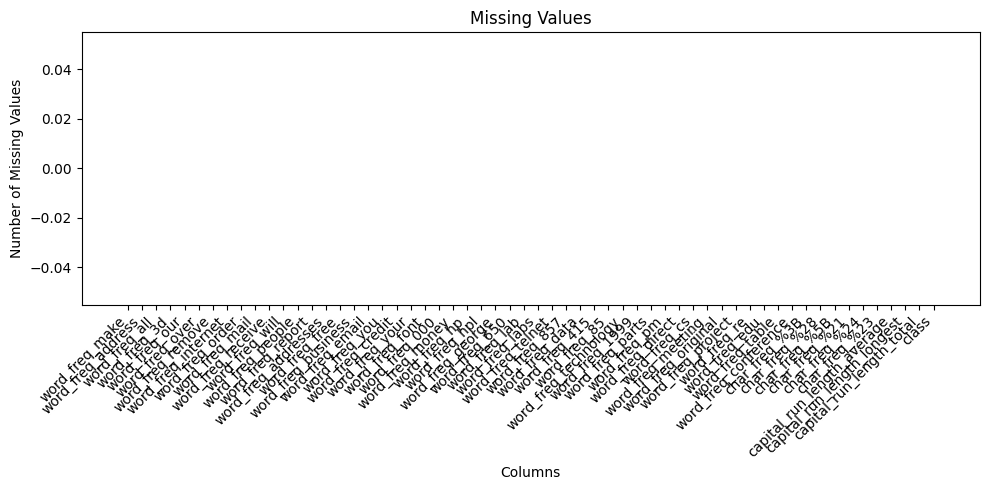


No columns have more than 50% missing values.

Numerical columns:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%2

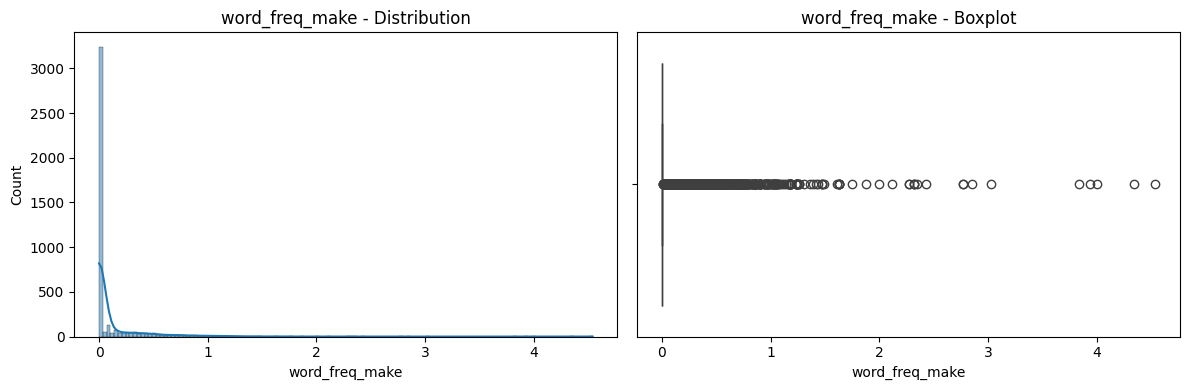

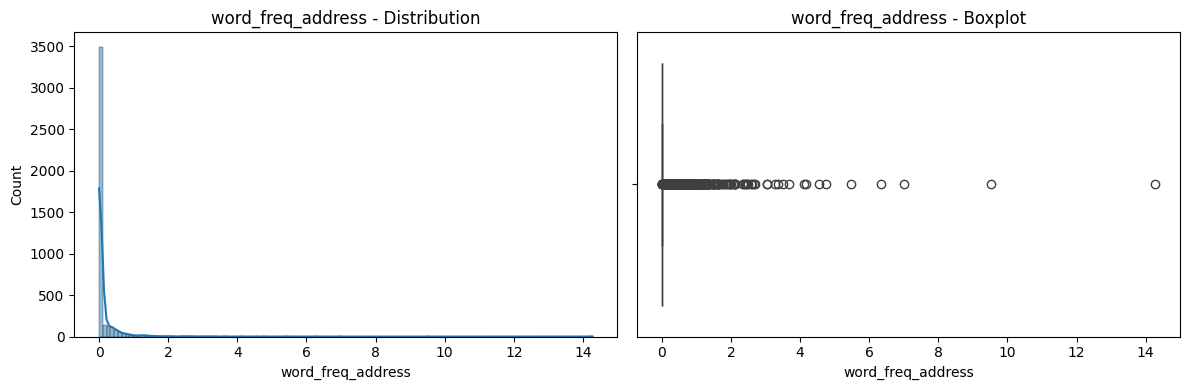

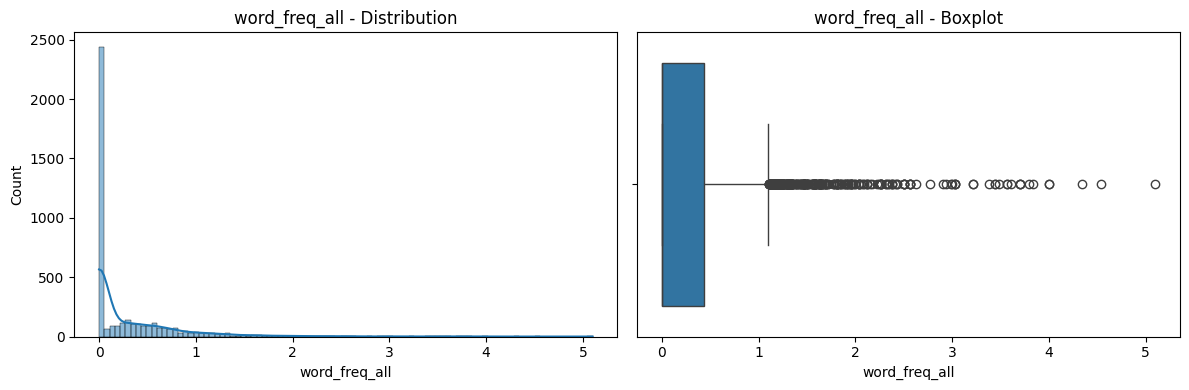

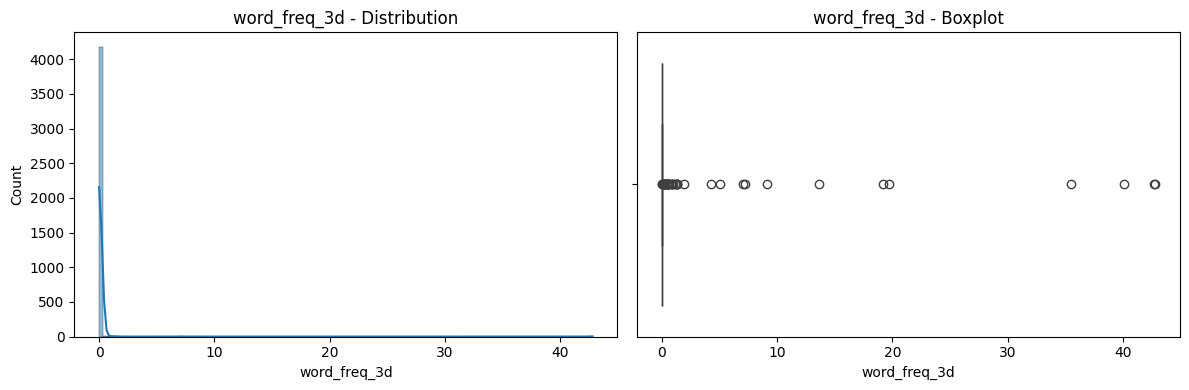

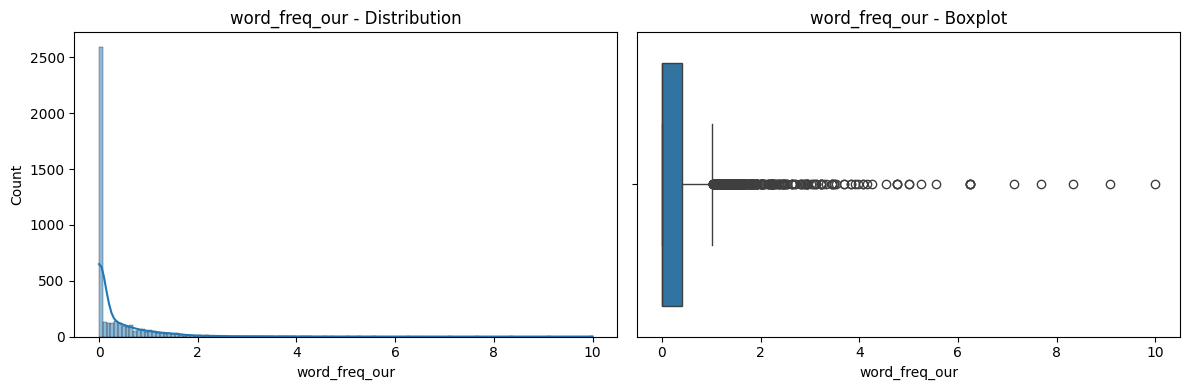

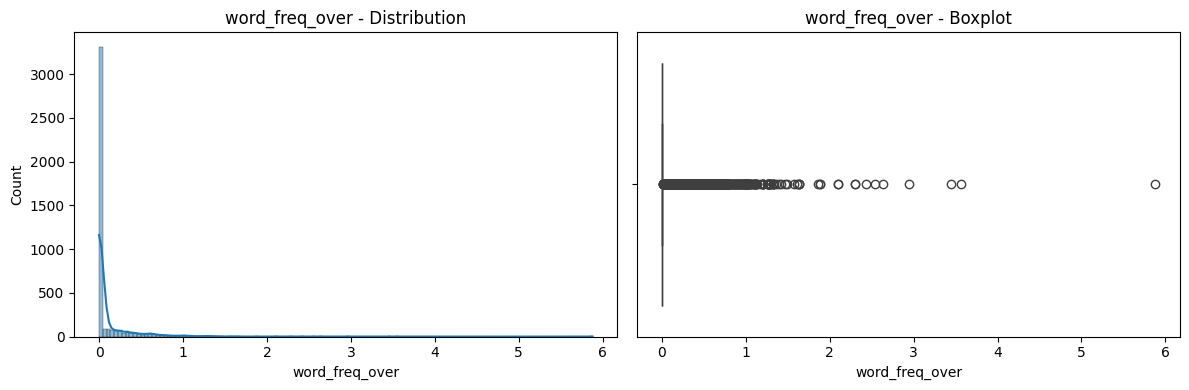

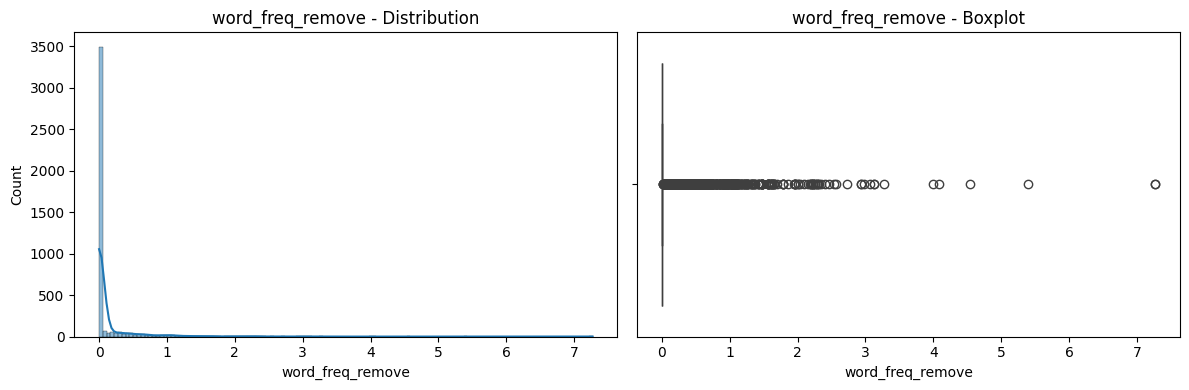

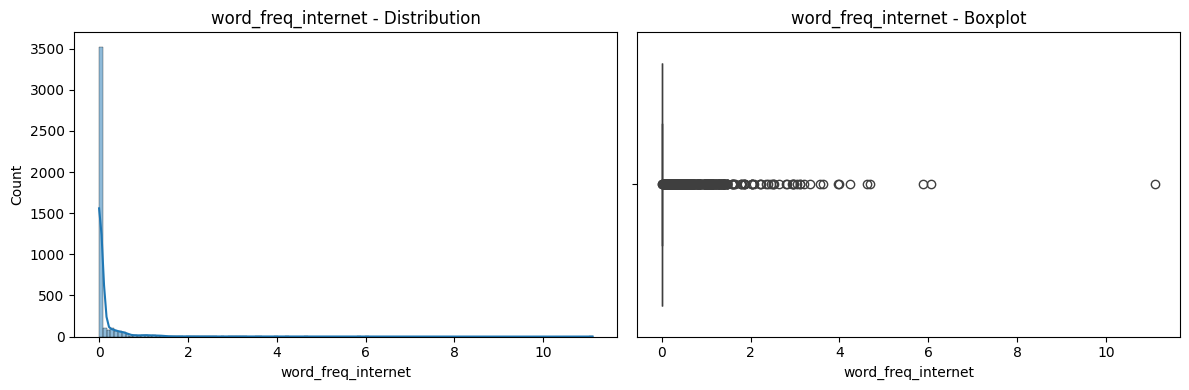

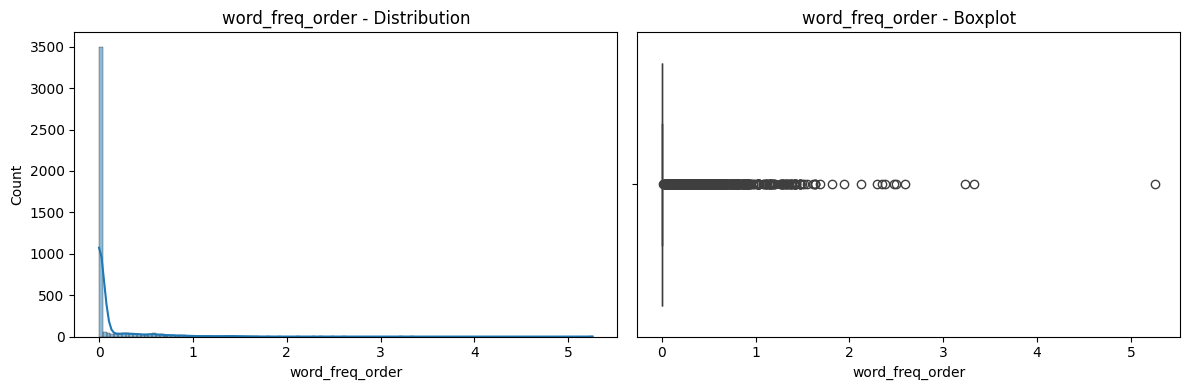

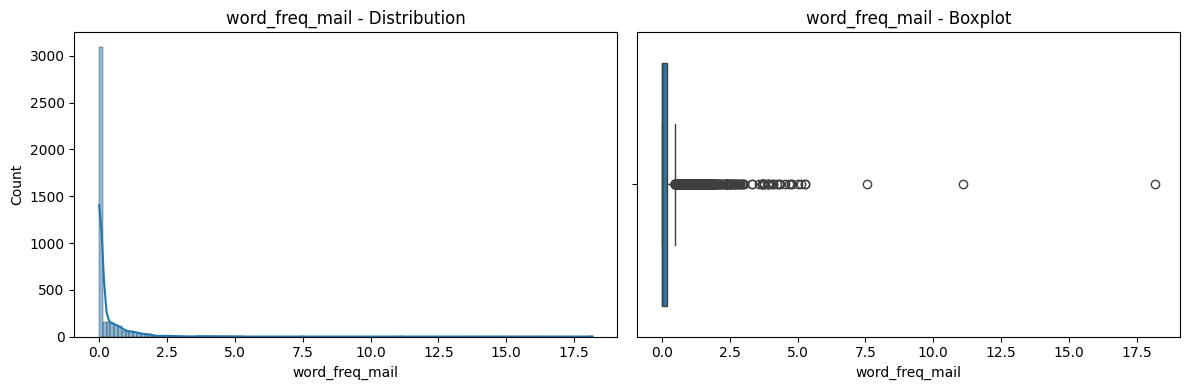

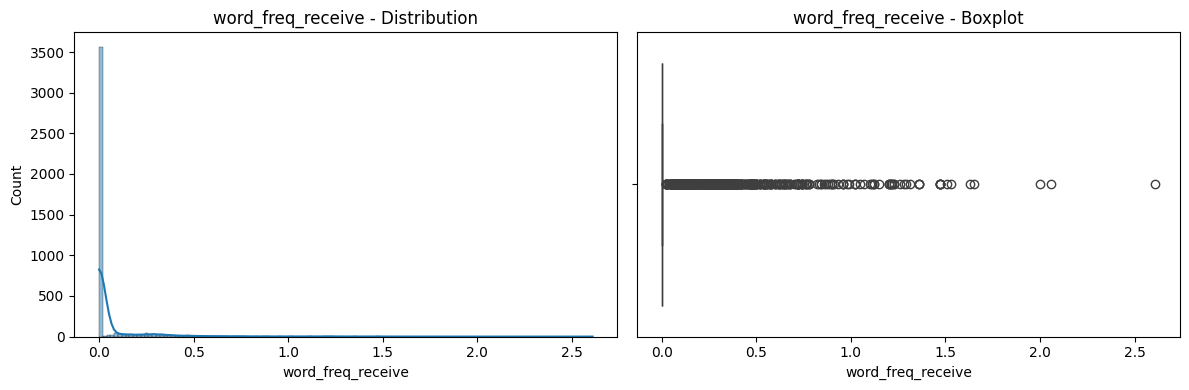

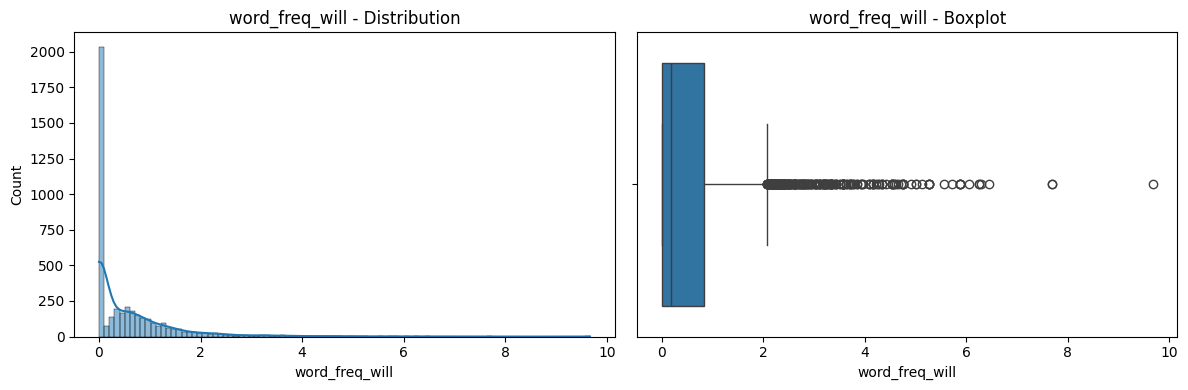

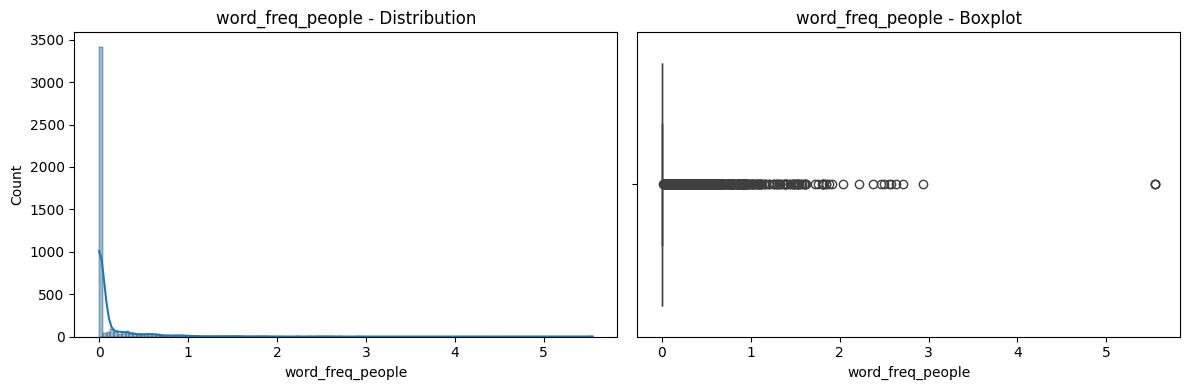

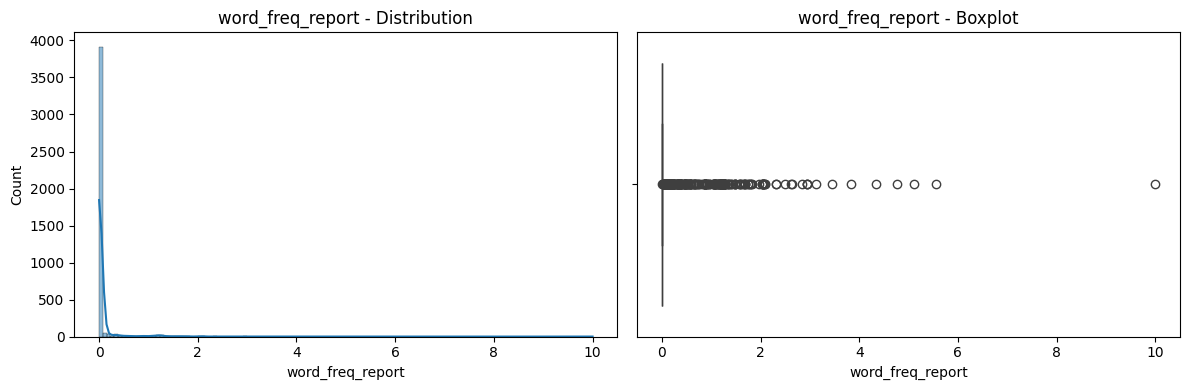

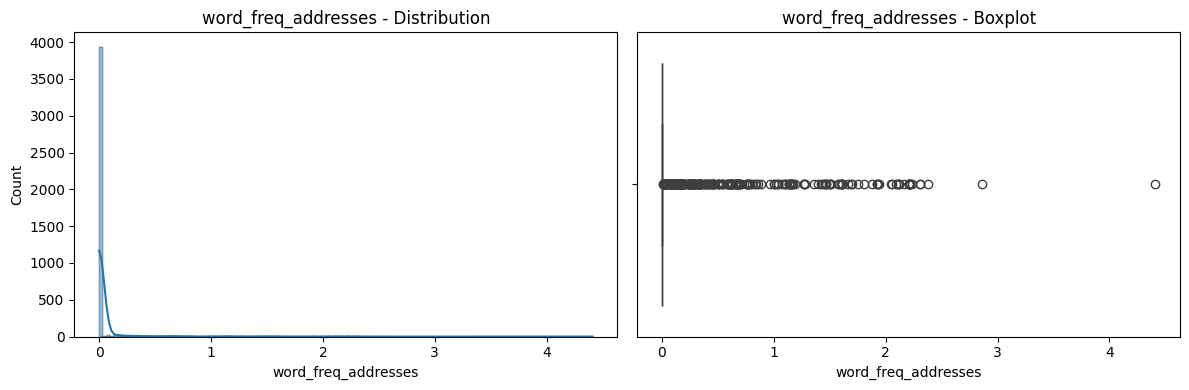

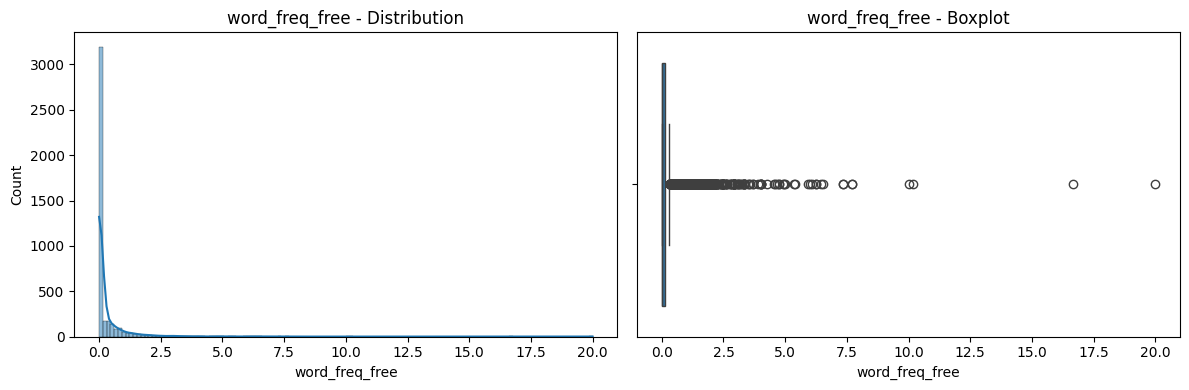

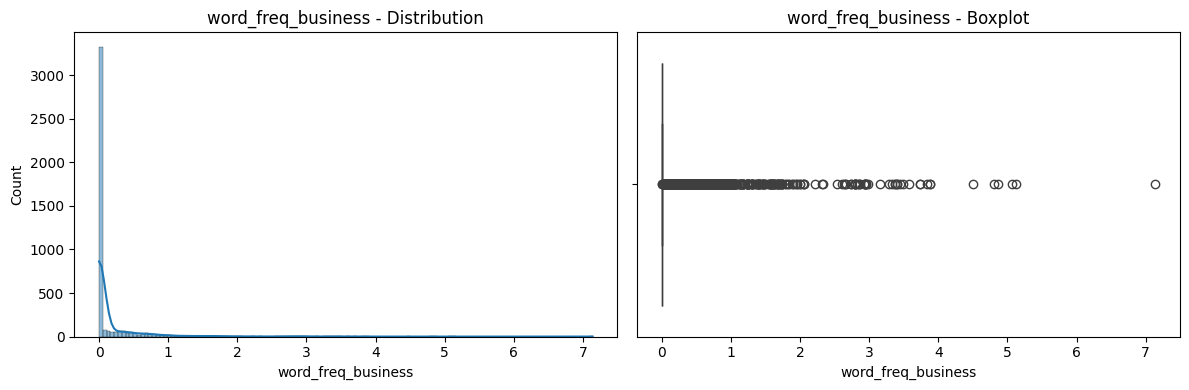

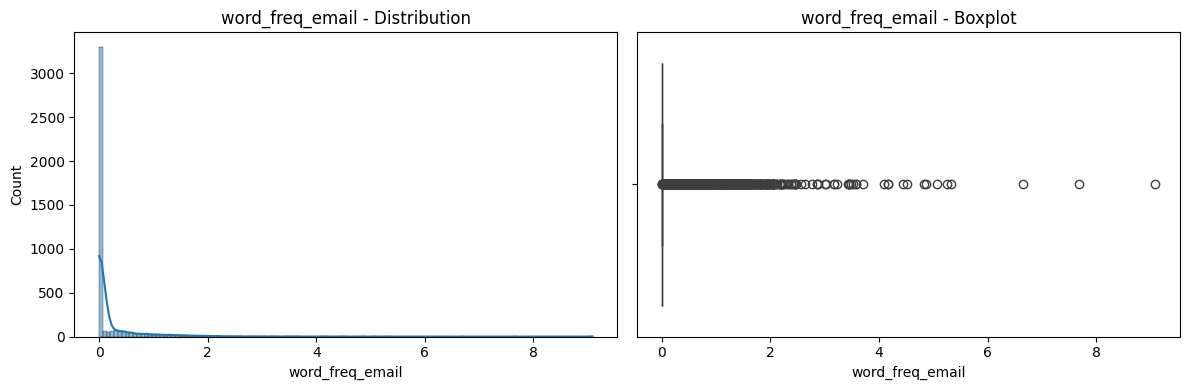

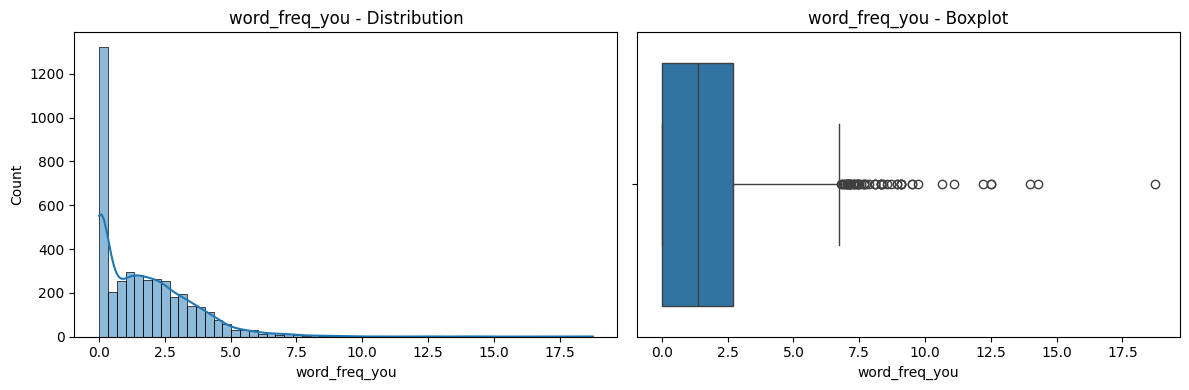

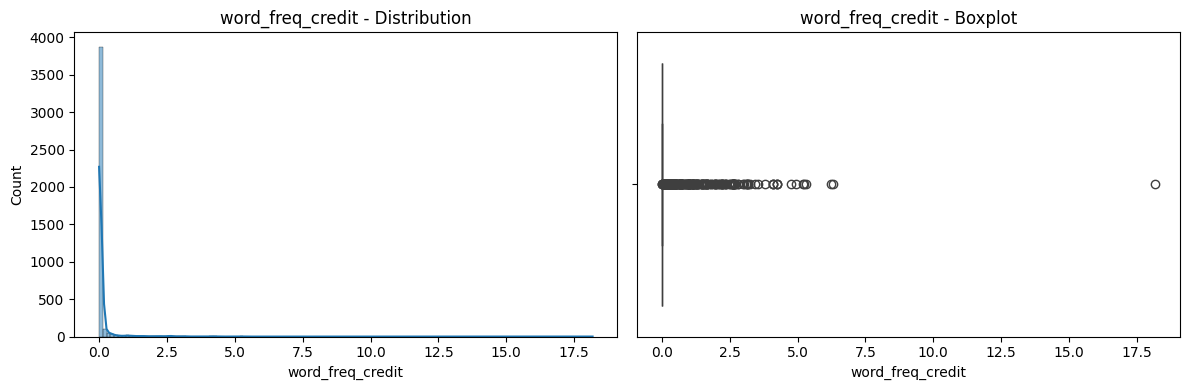

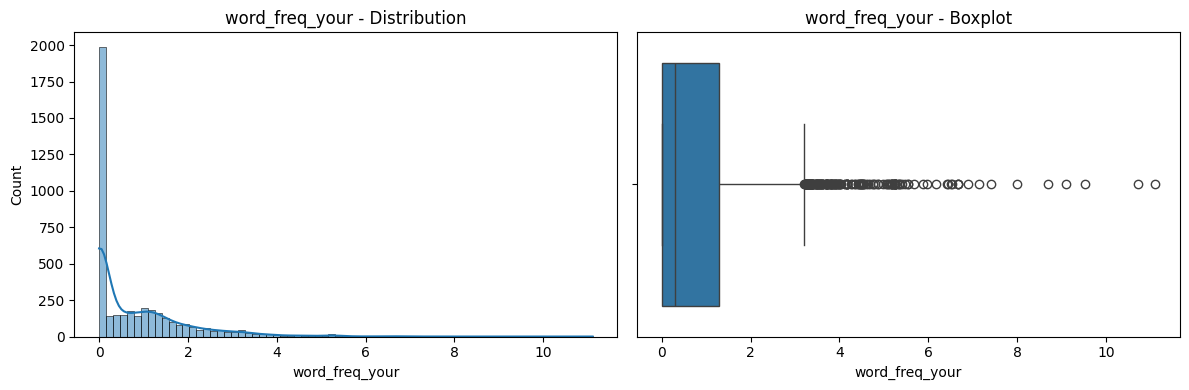

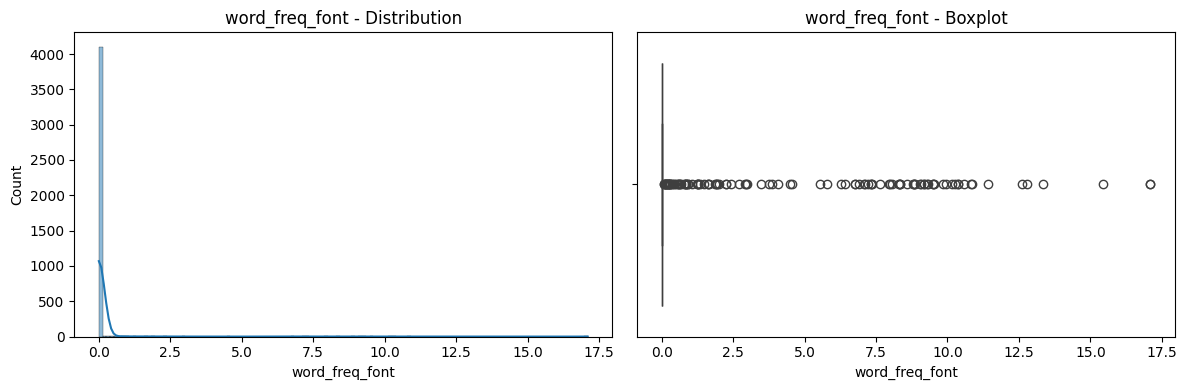

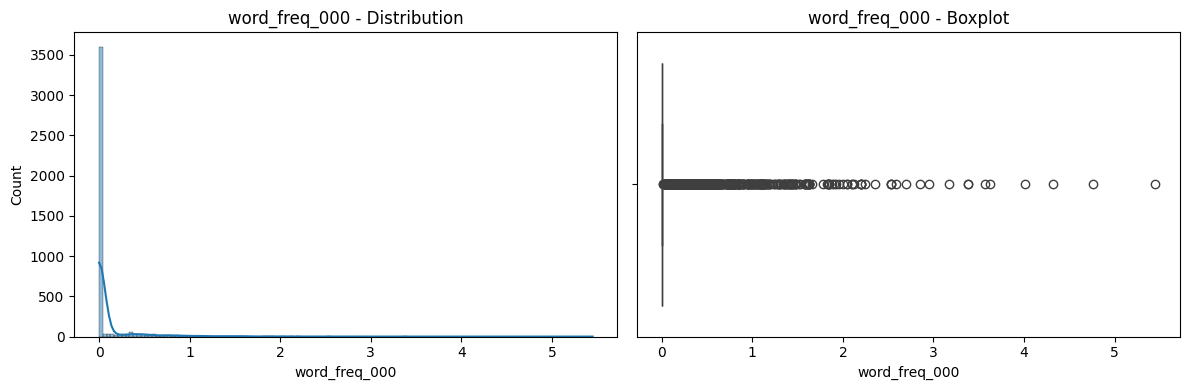

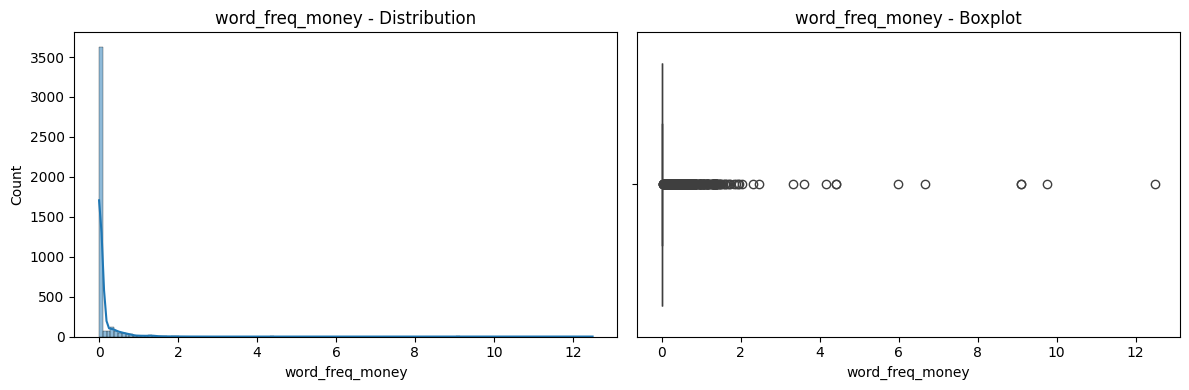

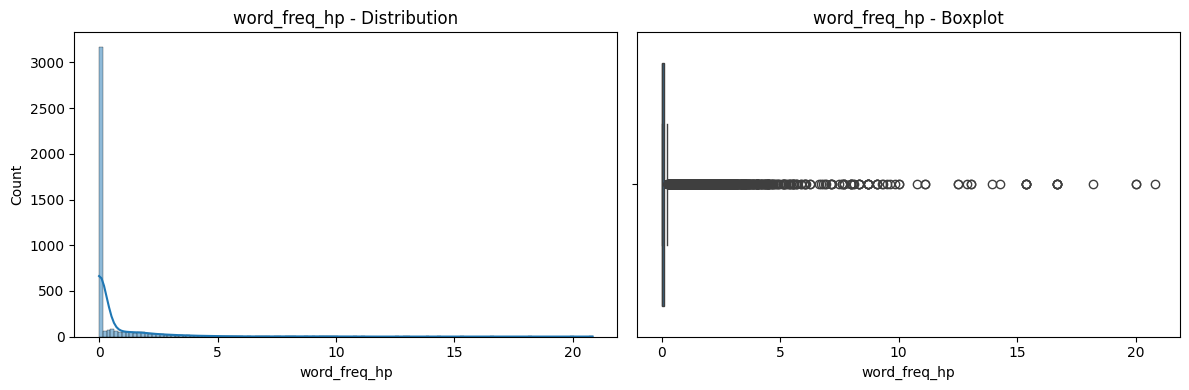

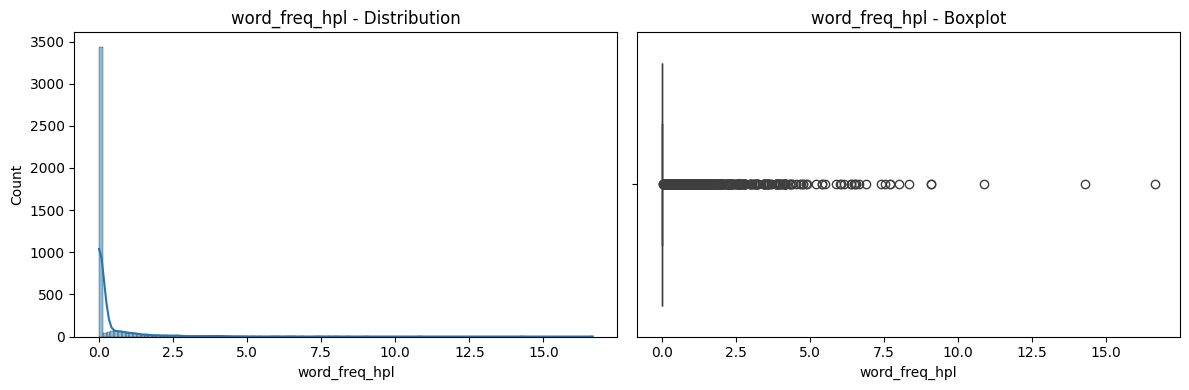

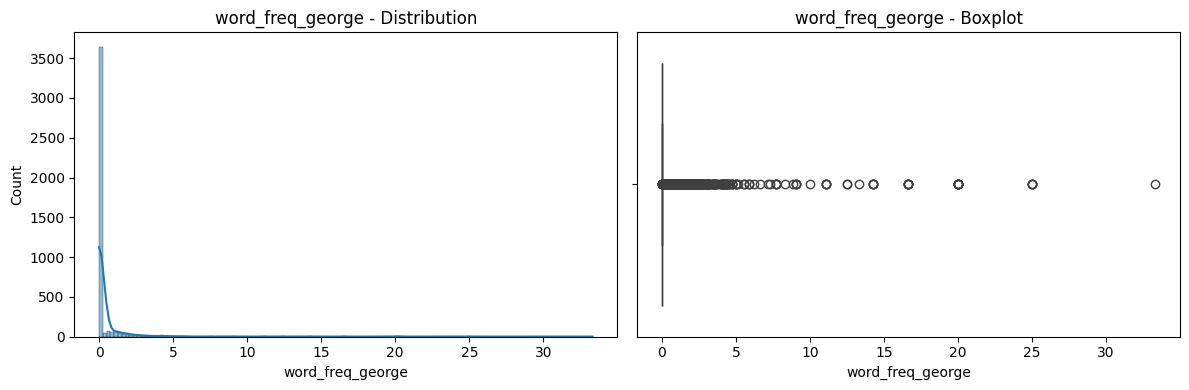

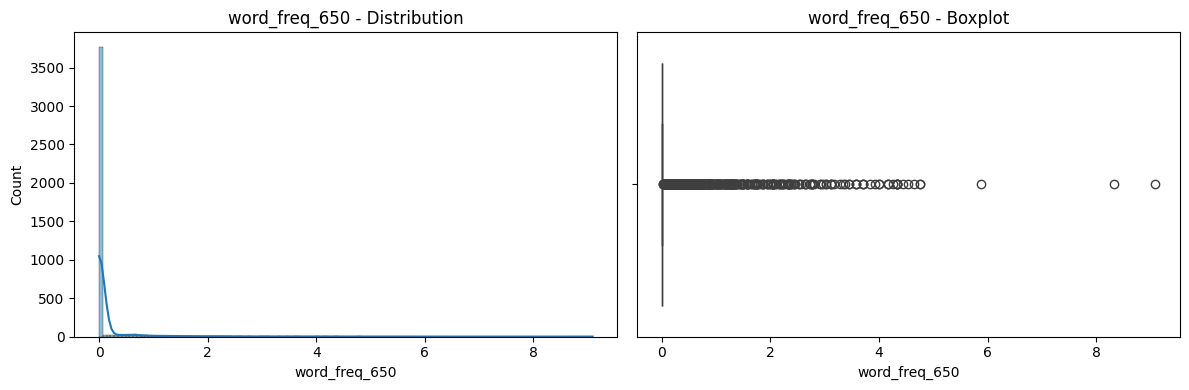

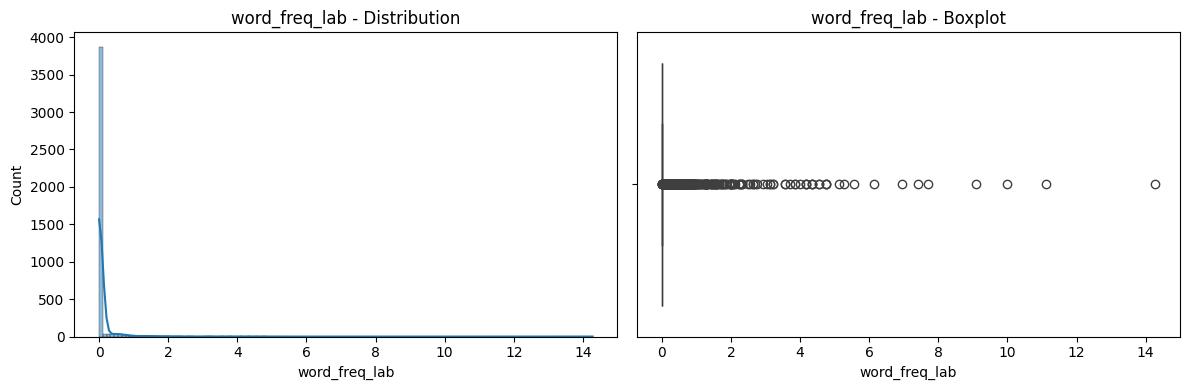

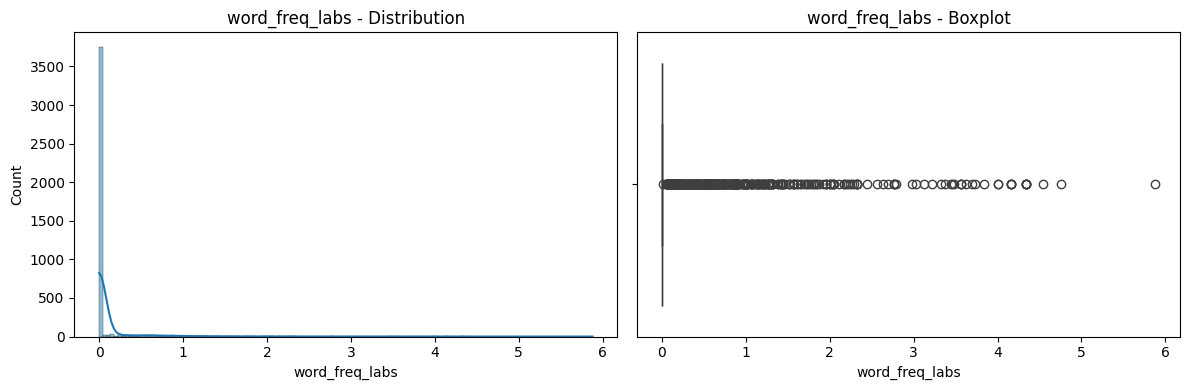

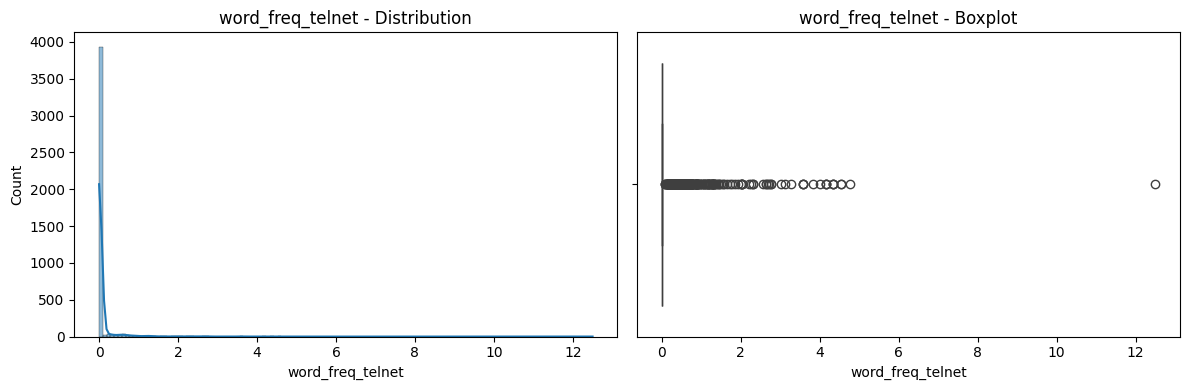

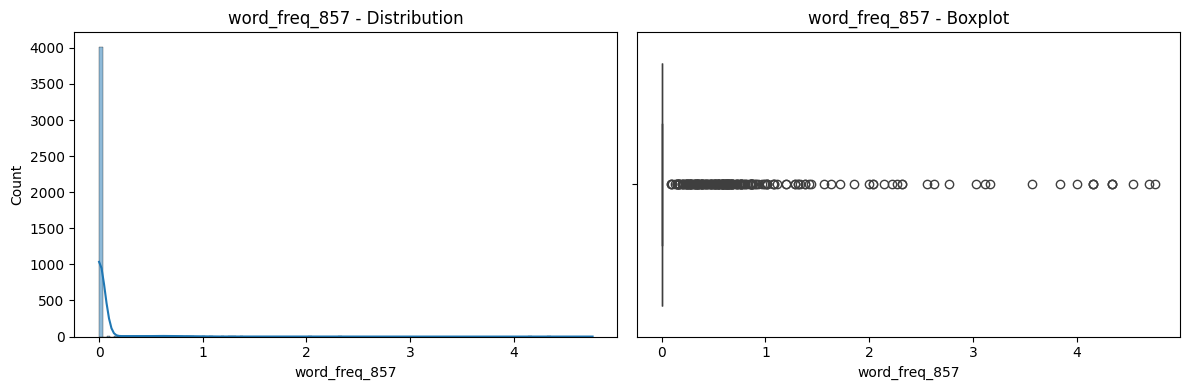

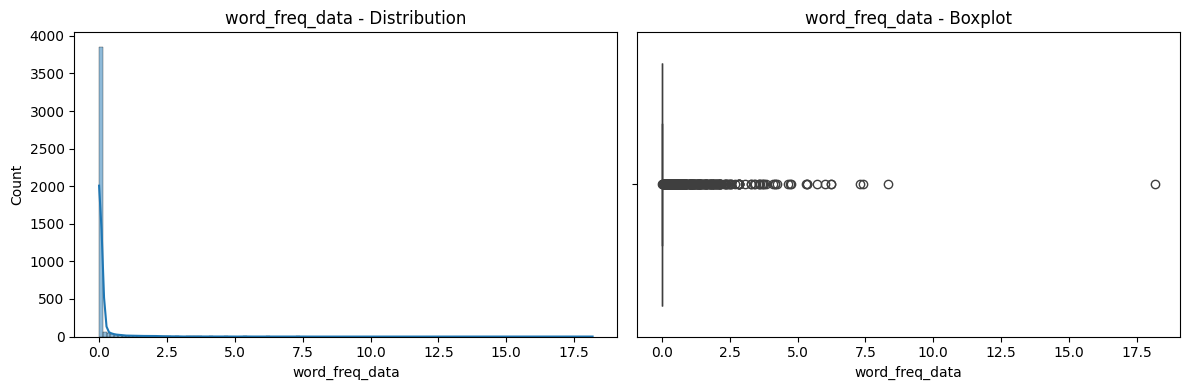

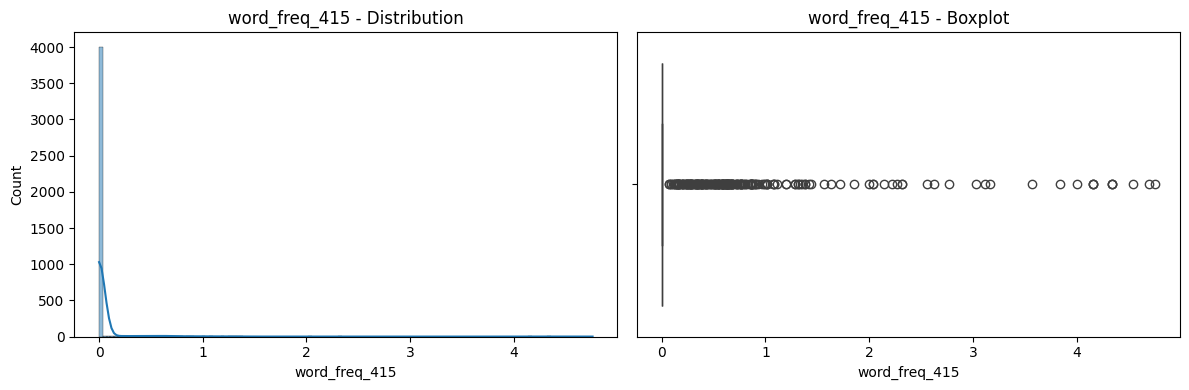

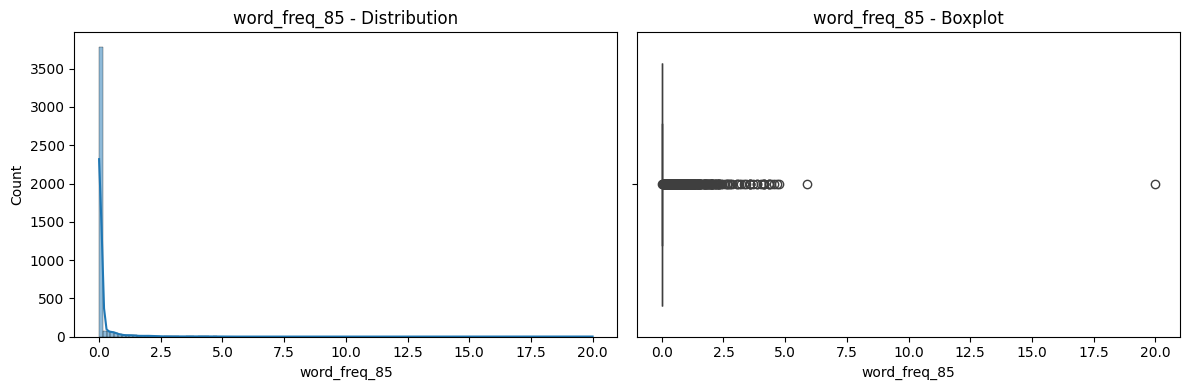

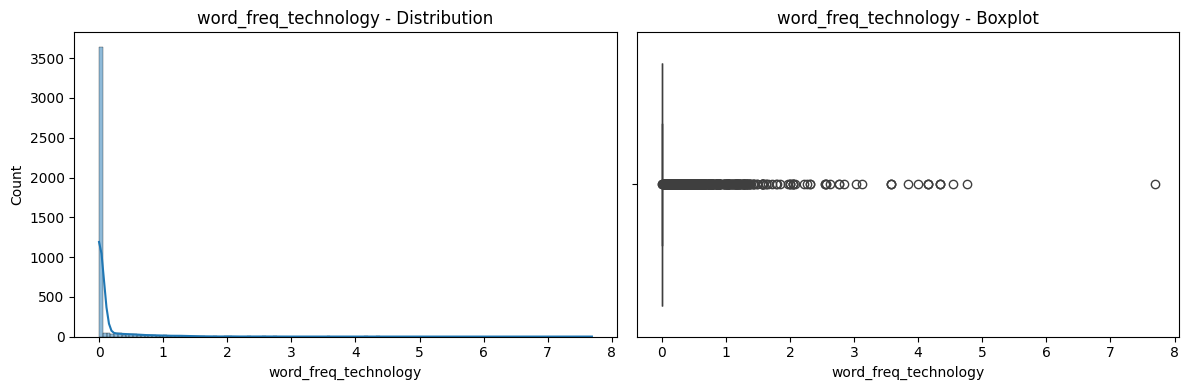

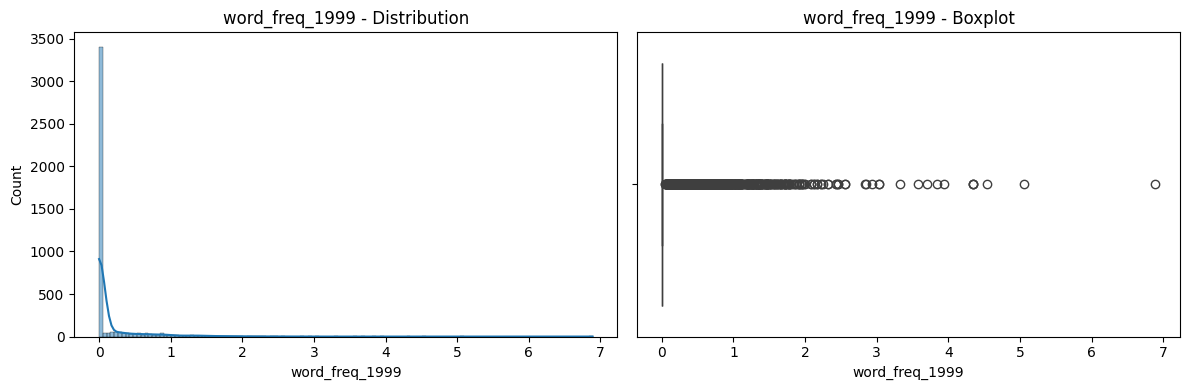

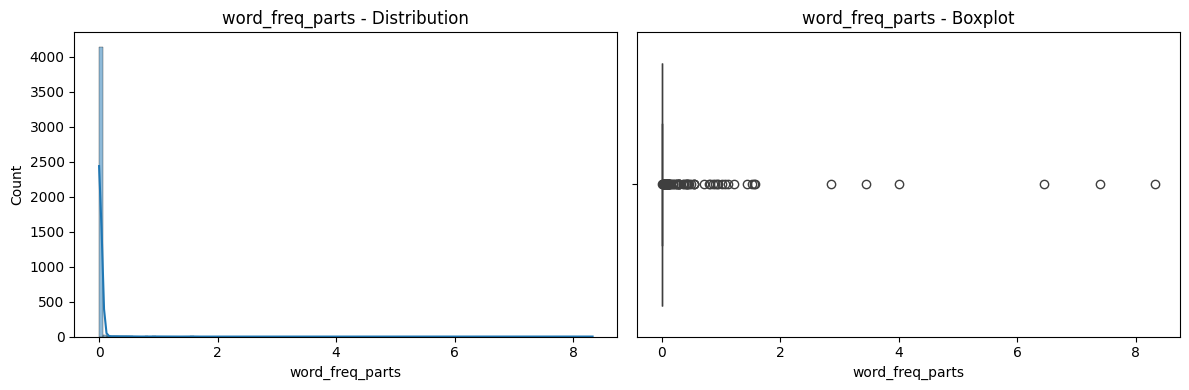

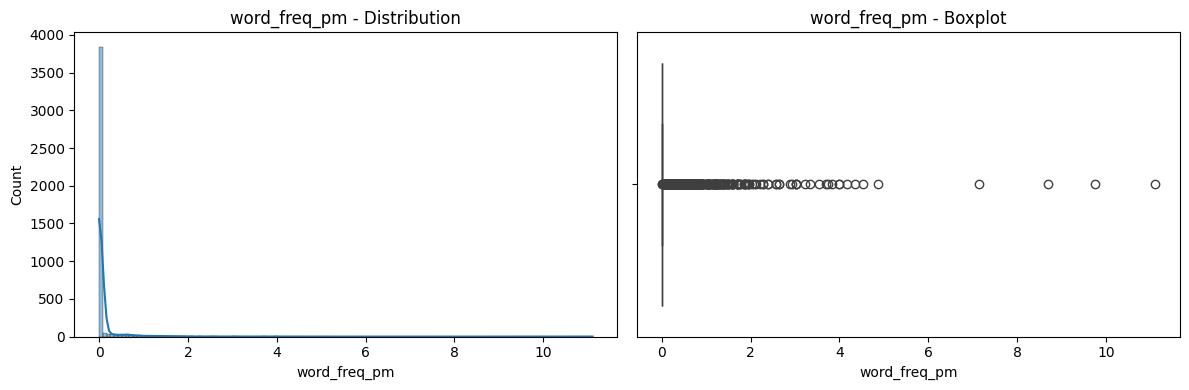

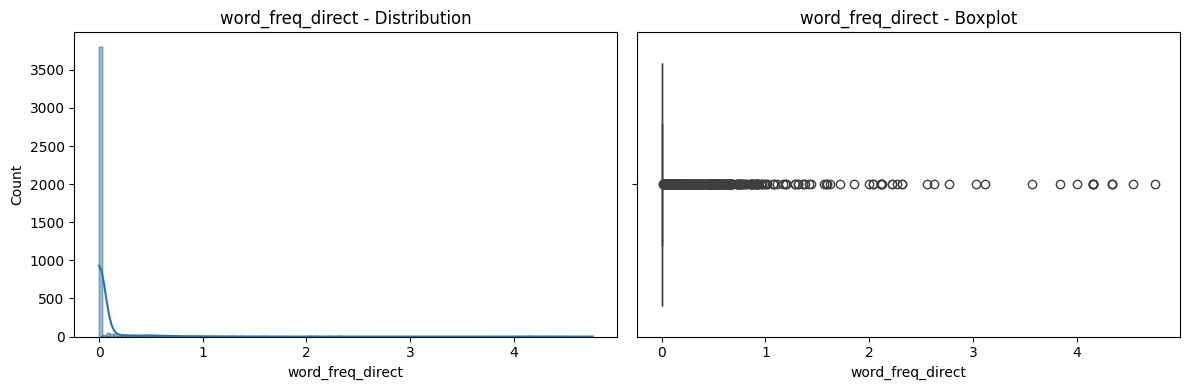

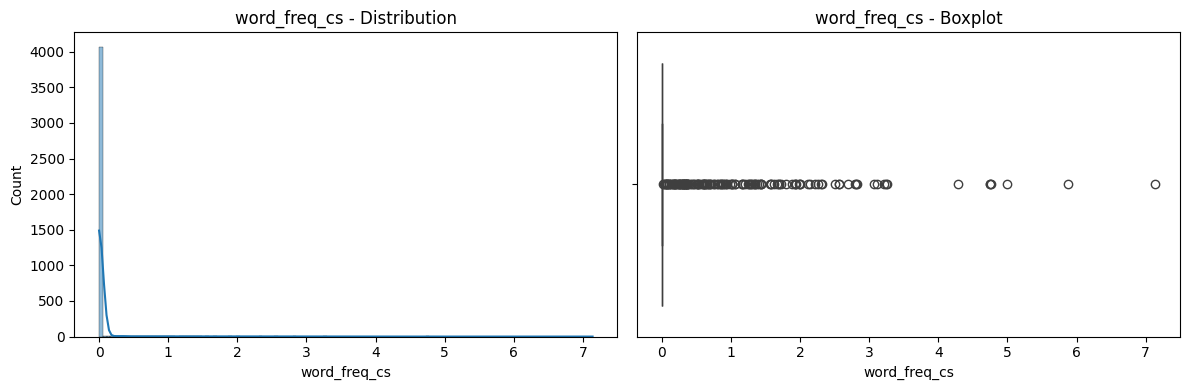

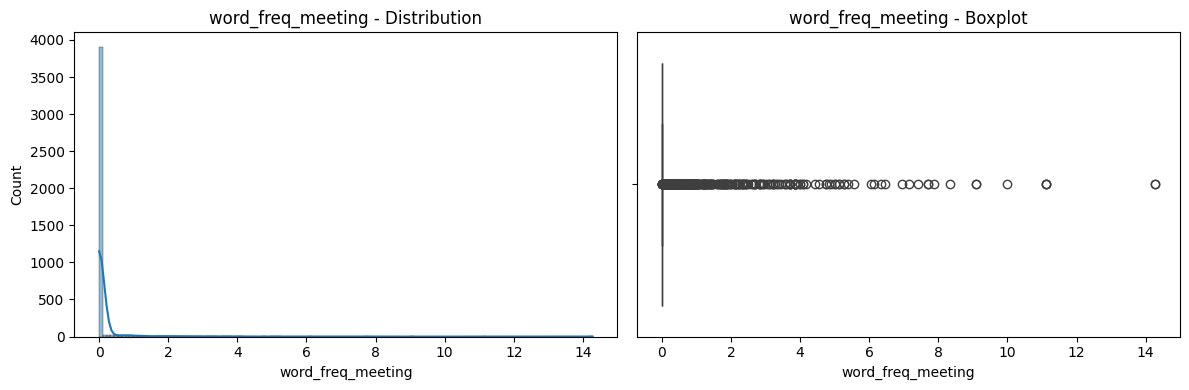

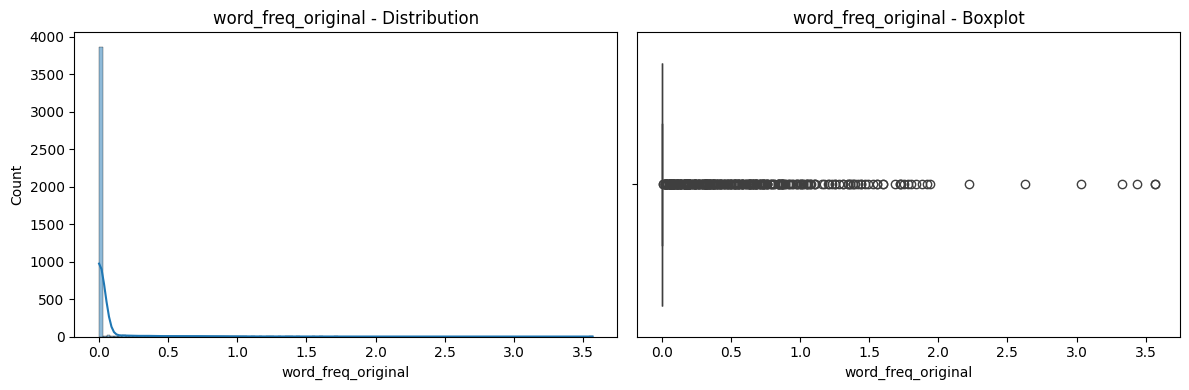

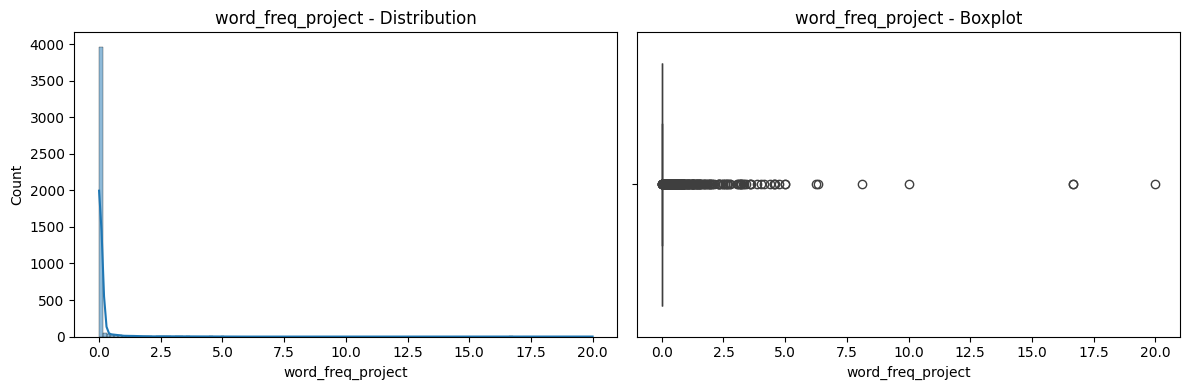

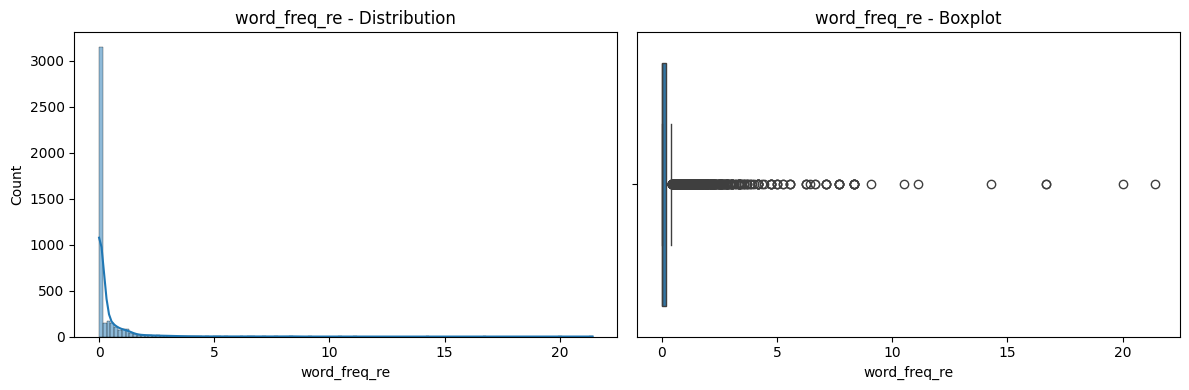

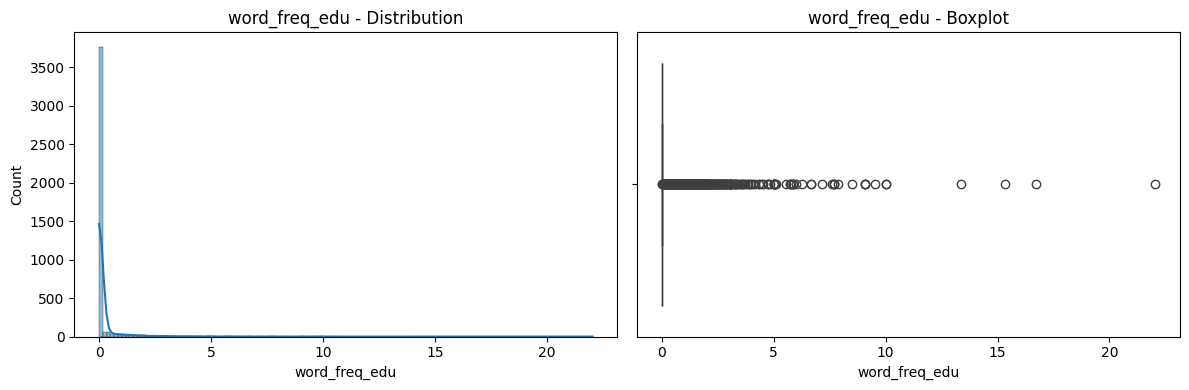

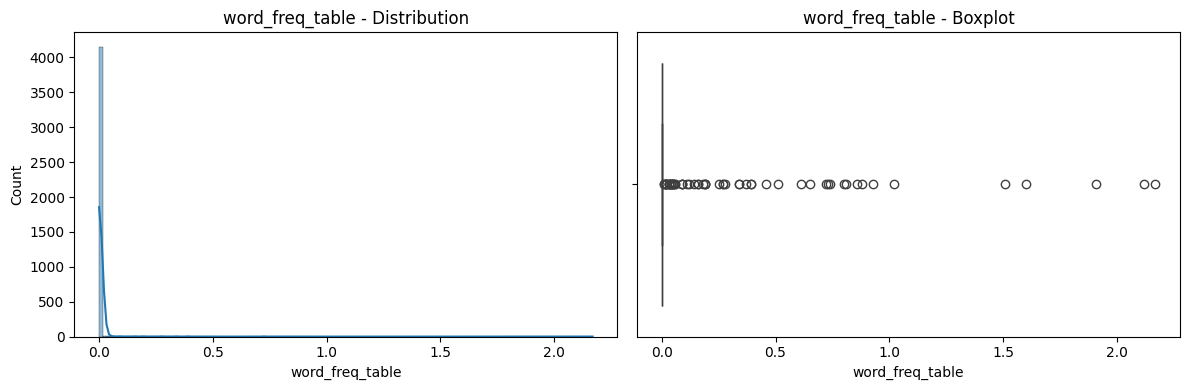

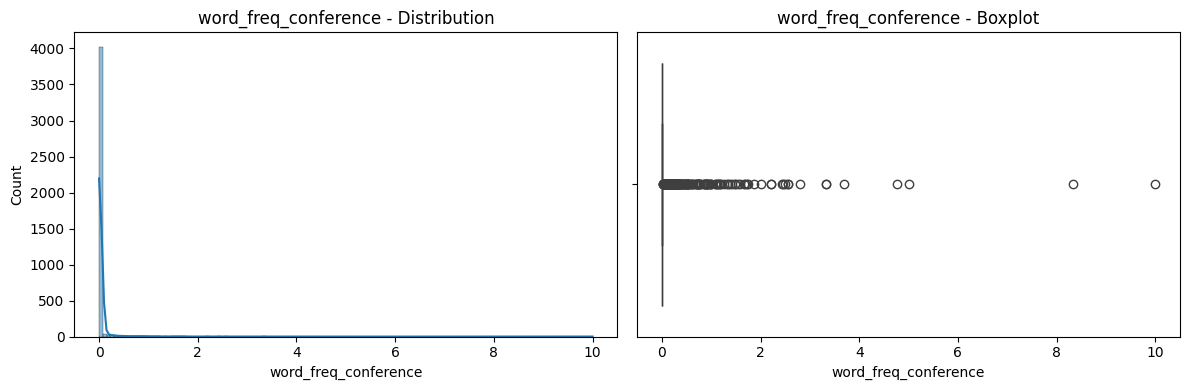

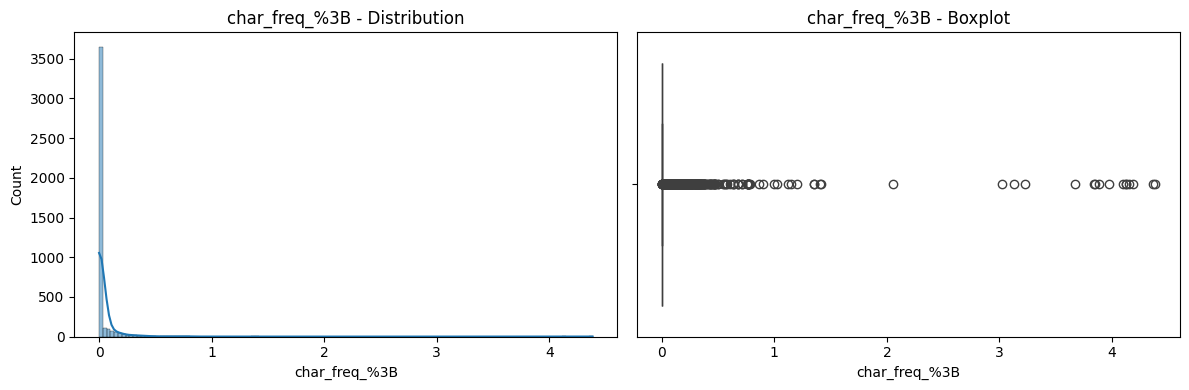

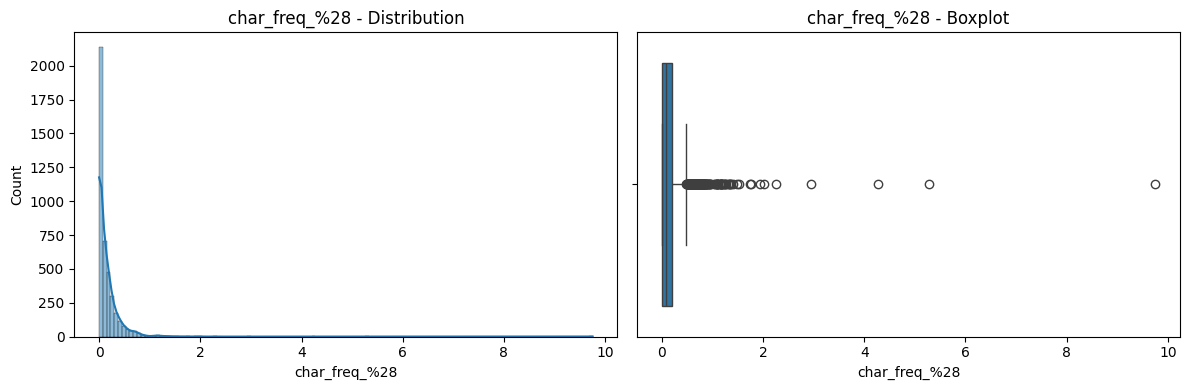

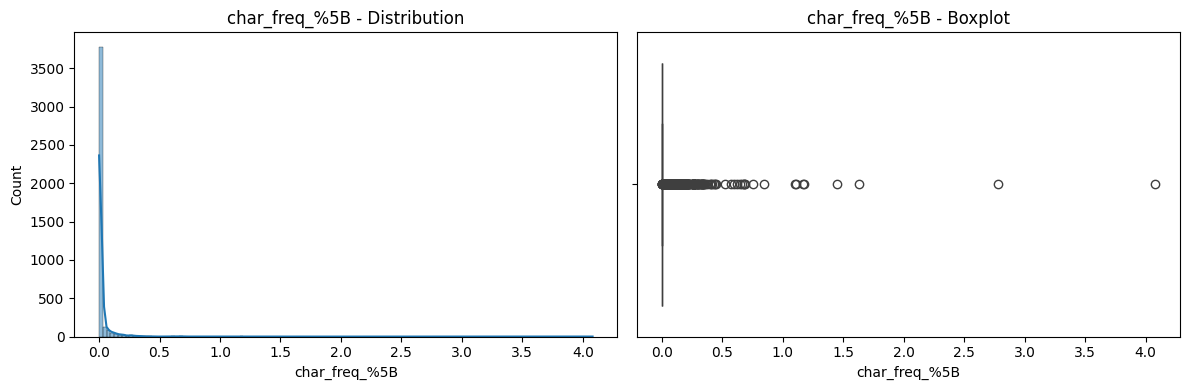

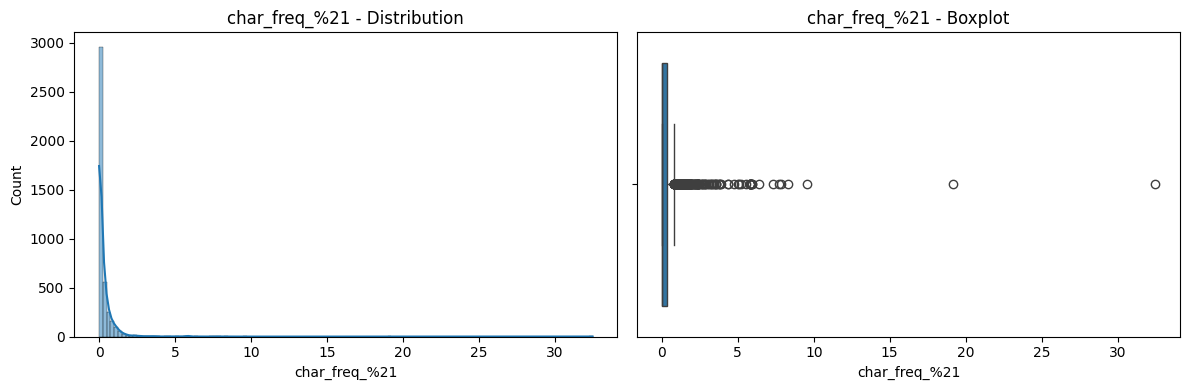

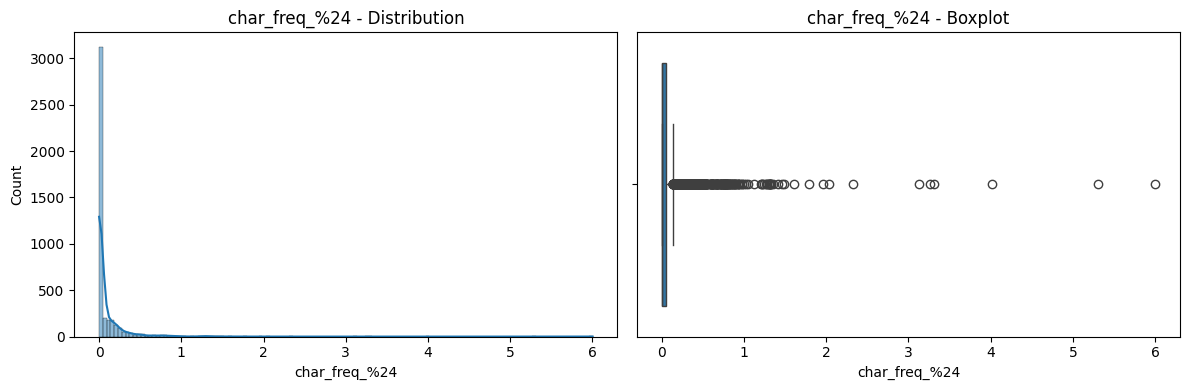

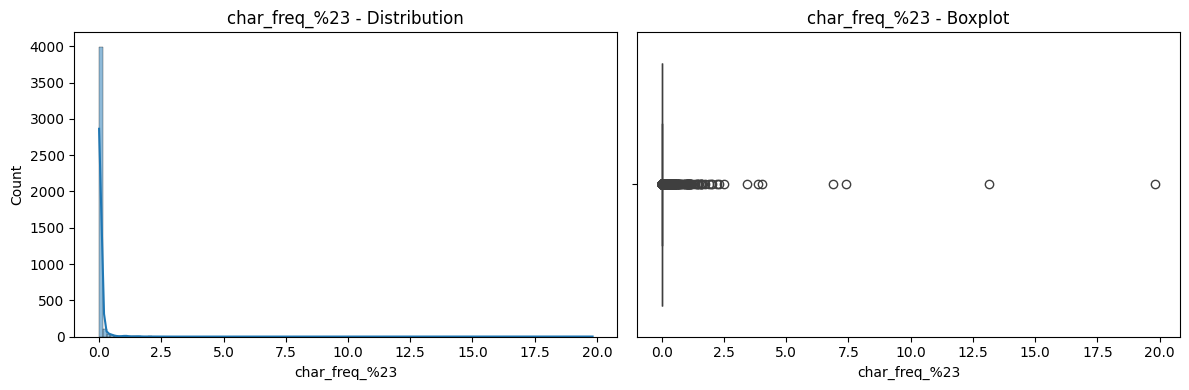

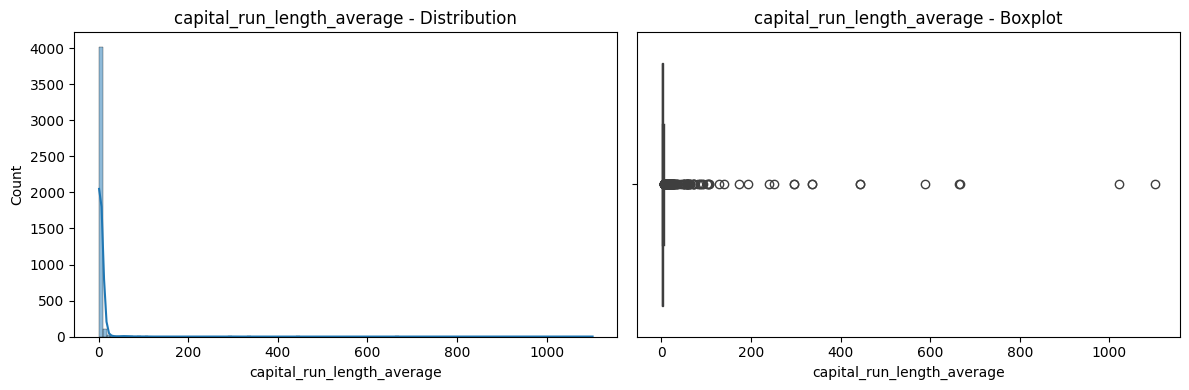

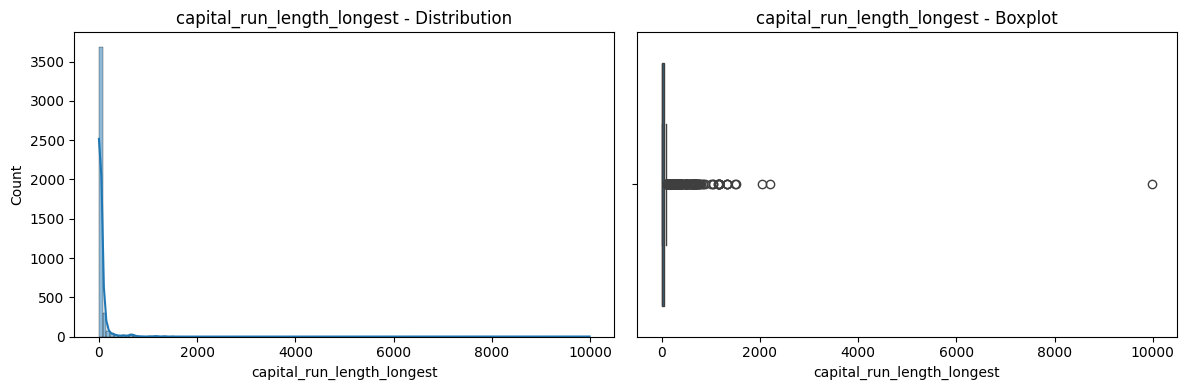

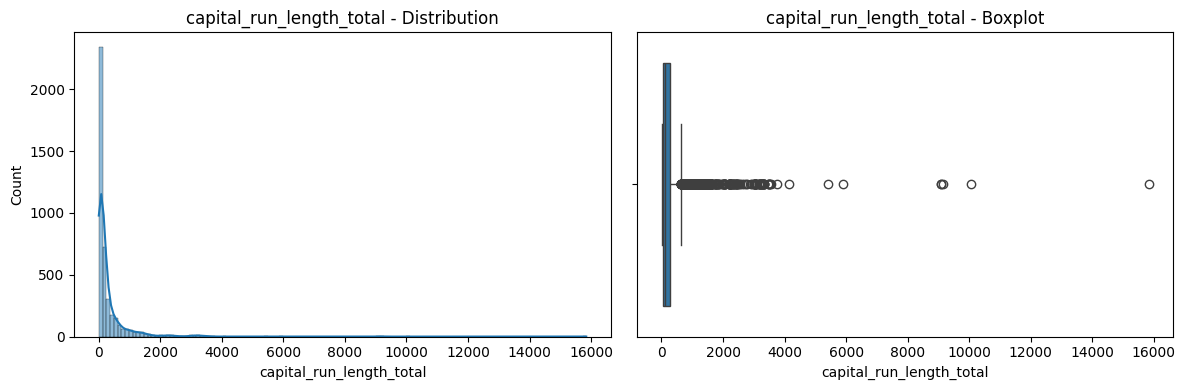

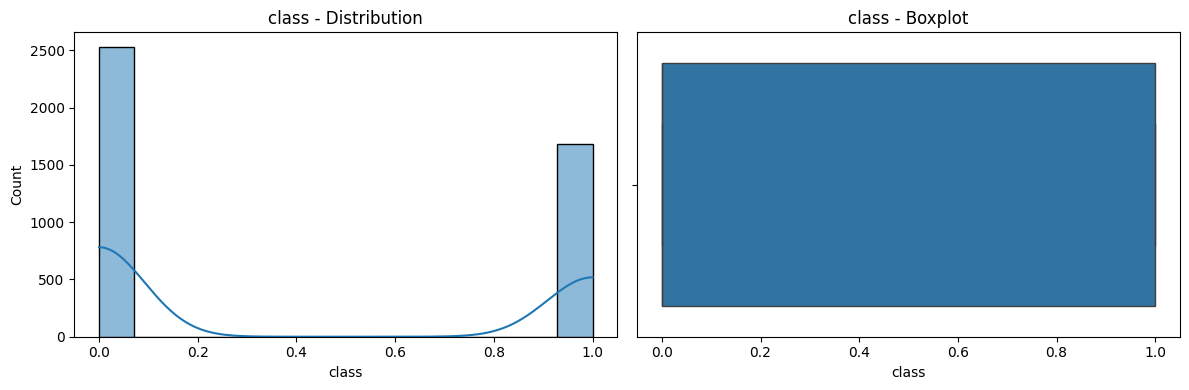

------------------------------------------------------------
CATEGORICAL FEATURE ANALYSIS
------------------------------------------------------------
CATEGORICAL ENCODING
------------------------------------------------------------
FINAL DATASET
Final dimensions: (4210, 58)
Remaining columns:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_pa

In [16]:
df = pd.read_csv("spambase_csv.csv")
df = eda(df)

## 2. Train and Test Data Split

In [17]:
from sklearn.model_selection import train_test_split
x = df.drop(columns=["class"])
y = df["class"]
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Training set: ",x_train.shape)
print("Testing set: ",x_test.shape)

Training set:  (3368, 57)
Testing set:  (842, 57)


## 3. Training Gaussian NB, Multinomial NB, Bernaulli NB, KNN

In [18]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import time

# GaussianNB

start = time.perf_counter()
gnb = GaussianNB()
gnb.fit(x_train, y_train)
y_pred_gnb = gnb.predict(x_test)
gnb_train_time = time.perf_counter() - start

# MultinomialNB

start = time.perf_counter()
mnb = MultinomialNB()
mnb.fit(x_train, y_train)
y_pred_mnb = mnb.predict(x_test)
mnb_train_time = time.perf_counter() - start

# BernaulliNB

start = time.perf_counter()
bnb = BernoulliNB()
bnb.fit(x_train, y_train)
y_pred_bnb = bnb.predict(x_test)
bnb_train_time = time.perf_counter() - start

# knn

start = time.perf_counter()
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_sc, y_train)
y_pred_knn = knn.predict(x_test_sc)
knn_train_time = time.perf_counter() - start

# performance metrics for GaussianNB

y_prob = gnb.predict_proba(x_test)[:, 1]
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
precision_gnb = precision_score(y_test, y_pred_gnb)
recall_gnb = recall_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb)
roc_auc_gnb = roc_auc_score(y_test, y_prob)
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
print("GAUSSIAN NB")
print("Accuracy :", accuracy_gnb)
print("Precision:", precision_gnb)
print("Recall   :", recall_gnb)
print("F1-score :", f1_gnb)
print("ROC-AUC  :", roc_auc_gnb)
print("Confusion Matrix:")
print(cm_gnb)
print("-" * 50)

# performance metrics for MultinomialNB
print("MULTINOMIAL NB")
y_prob = mnb.predict_proba(x_test)[:, 1]
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
precision_mnb = precision_score(y_test, y_pred_mnb)
recall_mnb = recall_score(y_test, y_pred_mnb)
f1_mnb = f1_score(y_test, y_pred_mnb)
roc_auc_mnb = roc_auc_score(y_test, y_prob)
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
print("Accuracy :", accuracy_mnb)
print("Precision:", precision_mnb)
print("Recall   :", recall_mnb)
print("F1-score :", f1_mnb)
print("ROC-AUC  :", roc_auc_mnb)
print("Confusion Matrix:")
print(cm_mnb)
print("-" * 50)

# performance metrics for BernauliNB

y_prob = bnb.predict_proba(x_test)[:, 1]
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
precision_bnb = precision_score(y_test, y_pred_bnb)
recall_bnb = recall_score(y_test, y_pred_bnb)
f1_bnb = f1_score(y_test, y_pred_bnb)
roc_auc_bnb = roc_auc_score(y_test, y_prob)
cm_bnb = confusion_matrix(y_test, y_pred_bnb)
print("BERNAULI NB")
print("Accuracy :", accuracy_bnb)
print("Precision:", precision_bnb)
print("Recall   :", recall_bnb)
print("F1-score :", f1_bnb)
print("ROC-AUC  :", roc_auc_bnb)
print("Confusion Matrix:")
print(cm_bnb)
print("-" * 50)

# performance metrics for KNN (n = 3)

y_prob = knn.predict_proba(x_test)[:, 1]
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_prob)
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("KNN")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1-score :", f1_knn)
print("ROC-AUC  :", roc_auc_knn)
print("Confusion Matrix:")
print(cm_knn)
print("-" * 50)

GAUSSIAN NB
Accuracy : 0.8467933491686461
Precision: 0.7467811158798283
Recall   : 0.9693593314763231
F1-score : 0.8436363636363636
ROC-AUC  : 0.9549819201024239
Confusion Matrix:
[[365 118]
 [ 11 348]]
--------------------------------------------------
MULTINOMIAL NB
Accuracy : 0.8040380047505938
Precision: 0.7869822485207101
Recall   : 0.7409470752089137
F1-score : 0.763271162123386
ROC-AUC  : 0.8478116691753605
Confusion Matrix:
[[411  72]
 [ 93 266]]
--------------------------------------------------
BERNAULI NB
Accuracy : 0.8812351543942993
Precision: 0.8960244648318043
Recall   : 0.8161559888579387
F1-score : 0.8542274052478134
ROC-AUC  : 0.948978356026921
Confusion Matrix:
[[449  34]
 [ 66 293]]
--------------------------------------------------
KNN
Accuracy : 0.8847980997624703
Precision: 0.8808139534883721
Recall   : 0.8440111420612814
F1-score : 0.8620199146514936
ROC-AUC  : 0.5702030600298736
Confusion Matrix:
[[442  41]
 [ 56 303]]
------------------------------------------

C:\Users\Logesh SD\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


## 4. Tuning KNN using GridSearchCV and RandomSearchCV

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# training using grid search CV

param_grid = {"n_neighbors": [3, 5, 7, 9, 11, 13, 15], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]}
grid_search = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5, scoring="accuracy",n_jobs=-1)
grid_search.fit(x_train_sc, y_train)
y_pred_knn_grid = grid_search.predict(x_test_sc)
print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

# performance metrics for KNN using GridSearchCV

y_prob = grid_search.predict_proba(x_test)[:, 1]
accuracy_knn_grid = accuracy_score(y_test, y_pred_knn_grid)
precision_knn_grid = precision_score(y_test, y_pred_knn_grid)
recall_knn_grid = recall_score(y_test, y_pred_knn_grid)
f1_knn_grid = f1_score(y_test, y_pred_knn_grid)
roc_auc_knn_grid = roc_auc_score(y_test, y_prob)
cm_knn_grid = confusion_matrix(y_test, y_pred_knn_grid)
print("GridSearchCV")
print("Accuracy :", accuracy_knn_grid)
print("Precision:", precision_knn_grid)
print("Recall   :", recall_knn_grid)
print("F1-score :", f1_knn_grid)
print("ROC-AUC  :", roc_auc_knn_grid)
print("Confusion Matrix:")
print(cm_knn_grid)
print("-" * 50)

# training using random search CV

param_dist = {"n_neighbors": randint(1, 31), "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan", "minkowski"]}
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_distributions=param_dist, n_iter=20, cv=5, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(x_train_sc, y_train)
y_pred_knn_random = random_search.predict(x_test_sc)
print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# performance metrics for KNN using RandomSearchCV

y_prob = random_search.predict_proba(x_test)[:, 1]
accuracy_knn_random = accuracy_score(y_test, y_pred_knn_random)
precision_knn_random = precision_score(y_test, y_pred_knn_random)
recall_knn_random = recall_score(y_test, y_pred_knn_random)
f1_knn_random = f1_score(y_test, y_pred_knn_random)
roc_auc_knn_random = roc_auc_score(y_test, y_prob)
cm_knn_random = confusion_matrix(y_test, y_pred_knn_random)
print("RandomSearchCV")
print("Accuracy :", accuracy_knn_random)
print("Precision:", precision_knn_random)
print("Recall   :", recall_knn_random)
print("F1-score :", f1_knn_random)
print("ROC-AUC  :", roc_auc_knn_random)
print("\nConfusion Matrix:")
print(cm_knn_random)
print("-" * 50)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best CV score: 0.9138963232084514
GridSearchCV
Accuracy : 0.9133016627078385
Precision: 0.949685534591195
Recall   : 0.841225626740947
F1-score : 0.8921713441654358
ROC-AUC  : 0.7567287784679089
Confusion Matrix:
[[467  16]
 [ 57 302]]
--------------------------------------------------


C:\Users\Logesh SD\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Best parameters: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Best CV score: 0.9136004691337339
RandomSearchCV
Accuracy : 0.9121140142517815
Precision: 0.9495268138801262
Recall   : 0.8384401114206128
F1-score : 0.8905325443786982
ROC-AUC  : 0.832237581965086

Confusion Matrix:
[[467  16]
 [ 58 301]]
--------------------------------------------------


C:\Users\Logesh SD\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


## 5. Training KD Tree and Ball Tree

In [20]:
knn_kd = KNeighborsClassifier(n_neighbors=5,algorithm="kd_tree")
knn_ball = KNeighborsClassifier(n_neighbors=5,algorithm="ball_tree")
start = time.time()
knn_kd.fit(x_train_sc, y_train)
train_time_kd = time.time() - start
start = time.time()
knn_ball.fit(x_train_sc, y_train)
train_time_ball = time.time() - start

y_pred_kd = knn_kd.predict(x_test_sc)
y_pred_ball = knn_ball.predict(x_test_sc)

# performance metric for KDTree

y_prob = knn_kd.predict_proba(x_test)[:, 1]
accuracy_kd = accuracy_score(y_test, y_pred_kd)
precision_kd = precision_score(y_test, y_pred_kd)
recall_kd = recall_score(y_test, y_pred_kd)
f1_kd = f1_score(y_test, y_pred_kd)
roc_auc_kd = roc_auc_score(y_test, y_prob)
cm_kd = confusion_matrix(y_test, y_pred_kd)
print("KDTree")
print("Accuracy :", accuracy_kd)
print("Precision:", precision_kd)
print("Recall   :", recall_kd)
print("F1-score :", f1_kd)
print("ROC-AUC  :", roc_auc_kd)
print("\nConfusion Matrix:")
print(cm_kd)
print("-" * 50)
# performance metric for Ball Tree

y_prob = knn_ball.predict_proba(x_test)[:, 1]
accuracy_ball = accuracy_score(y_test, y_pred_ball)
precision_ball = precision_score(y_test, y_pred_ball)
recall_ball = recall_score(y_test, y_pred_ball)
f1_ball = f1_score(y_test, y_pred_ball)
roc_auc_ball = roc_auc_score(y_test, y_prob)
cm_ball = confusion_matrix(y_test, y_pred_ball)
print("Ball Tree")
print("Accuracy :", accuracy_ball)
print("Precision:", precision_ball)
print("Recall   :", recall_ball)
print("F1-score :", f1_ball)
print("ROC-AUC  :", roc_auc_ball)
print("\nConfusion Matrix:")
print(cm_ball)
print("-" * 50)

C:\Users\Logesh SD\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\Logesh SD\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


KDTree
Accuracy : 0.8836104513064132
Precision: 0.8942598187311178
Recall   : 0.8245125348189415
F1-score : 0.8579710144927536
ROC-AUC  : 0.702788975587813

Confusion Matrix:
[[448  35]
 [ 63 296]]
--------------------------------------------------
Ball Tree
Accuracy : 0.8836104513064132
Precision: 0.8942598187311178
Recall   : 0.8245125348189415
F1-score : 0.8579710144927536
ROC-AUC  : 0.702788975587813

Confusion Matrix:
[[448  35]
 [ 63 296]]
--------------------------------------------------


In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
knn_cv = KNeighborsClassifier(metric='manhattan', n_neighbors=6, weights='distance')
scores_bnb = cross_val_score(bnb,x_train,y_train,cv=cv,scoring="accuracy")
scores_knn = cross_val_score(knn,x_train_sc,y_train,cv=cv,scoring="accuracy")
print("BernoulliNB Fold Scores:", scores_bnb)
print("KNN Fold Scores:", scores_knn)

BernoulliNB Fold Scores: [0.89020772 0.89020772 0.88278932 0.87221397 0.897474  ]
KNN Fold Scores: [0.884273   0.89317507 0.90504451 0.89598811 0.91381872]


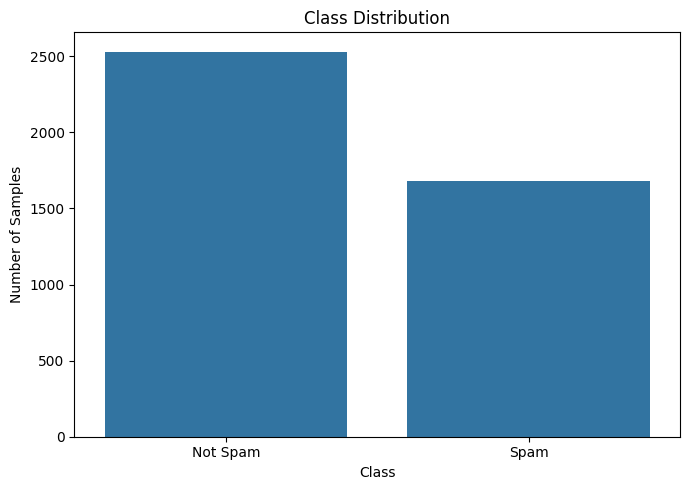

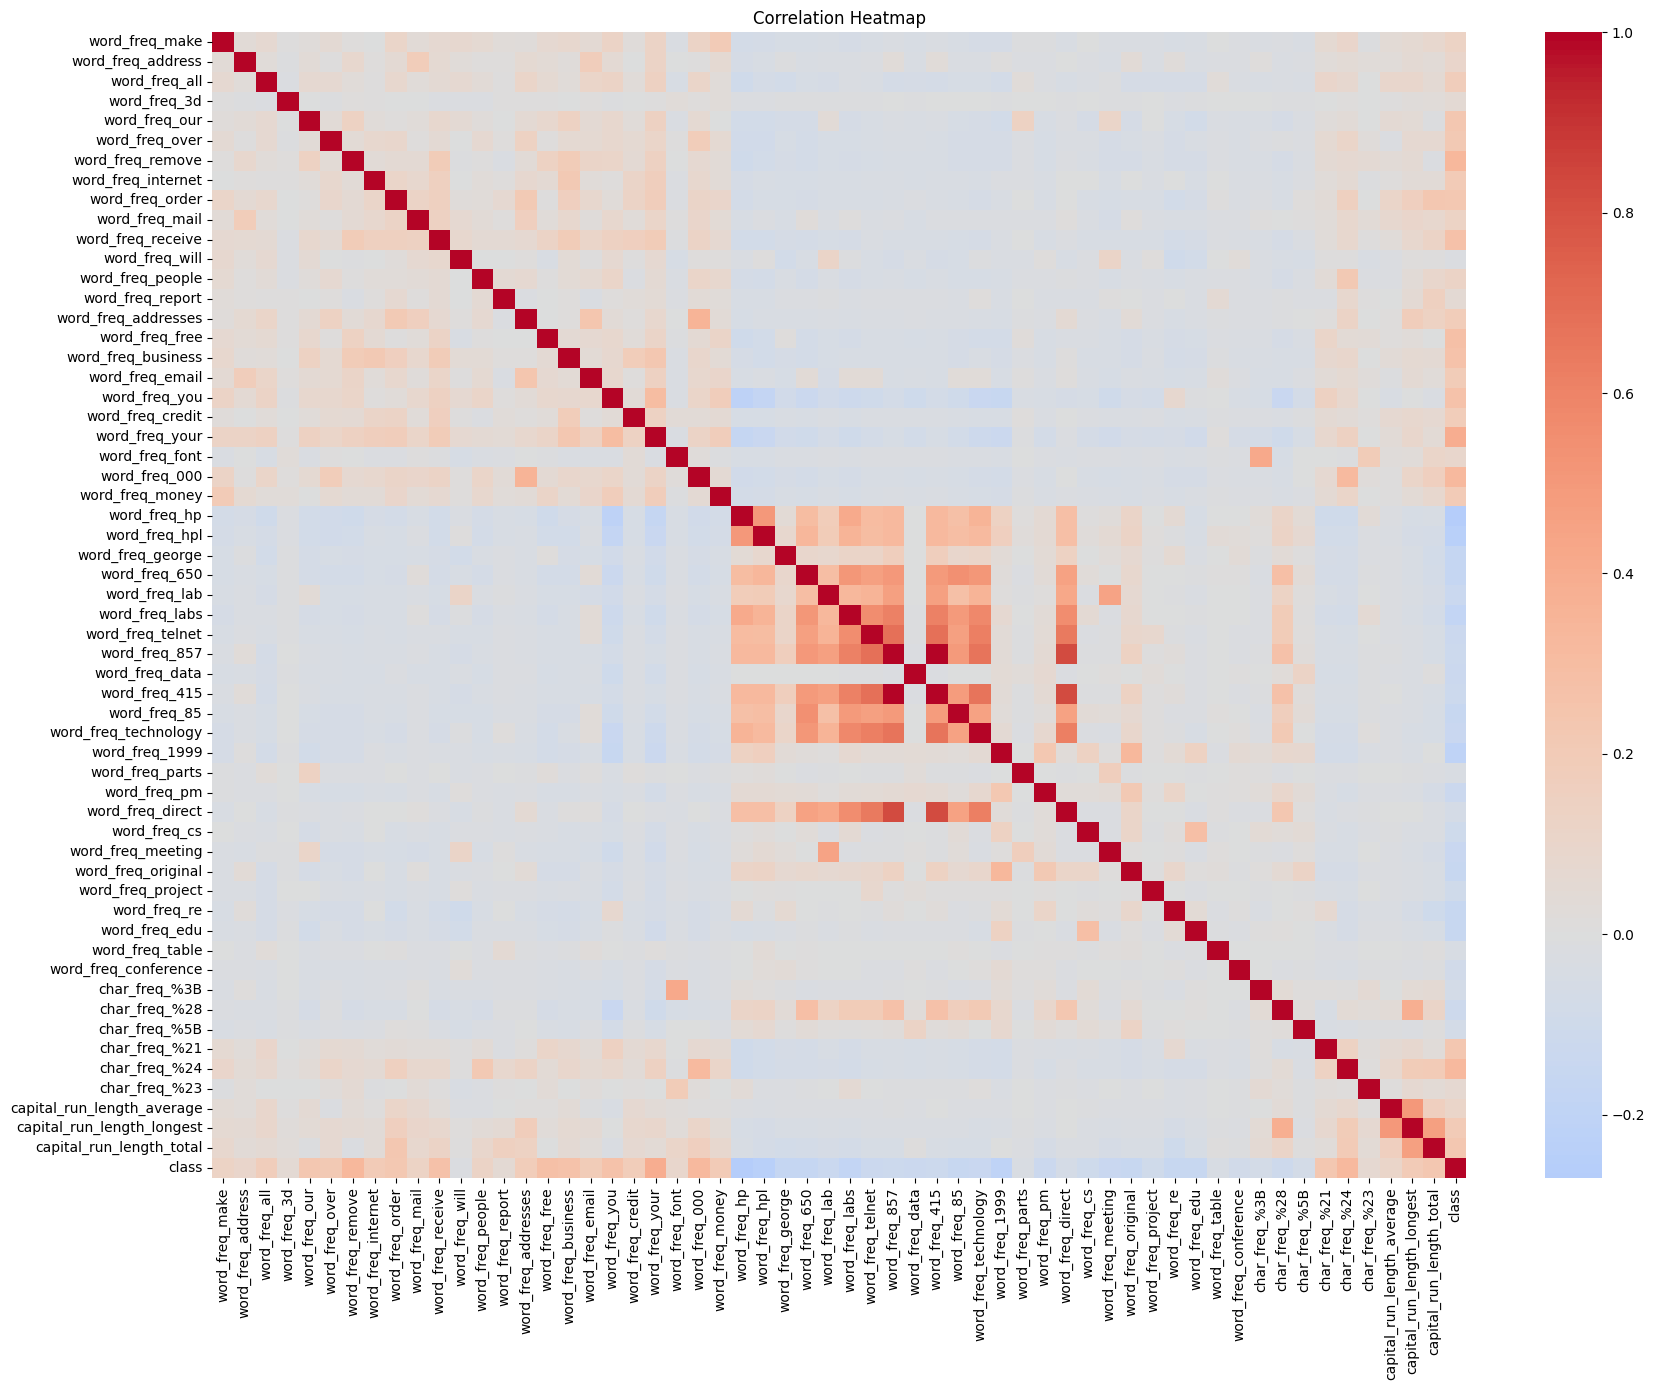

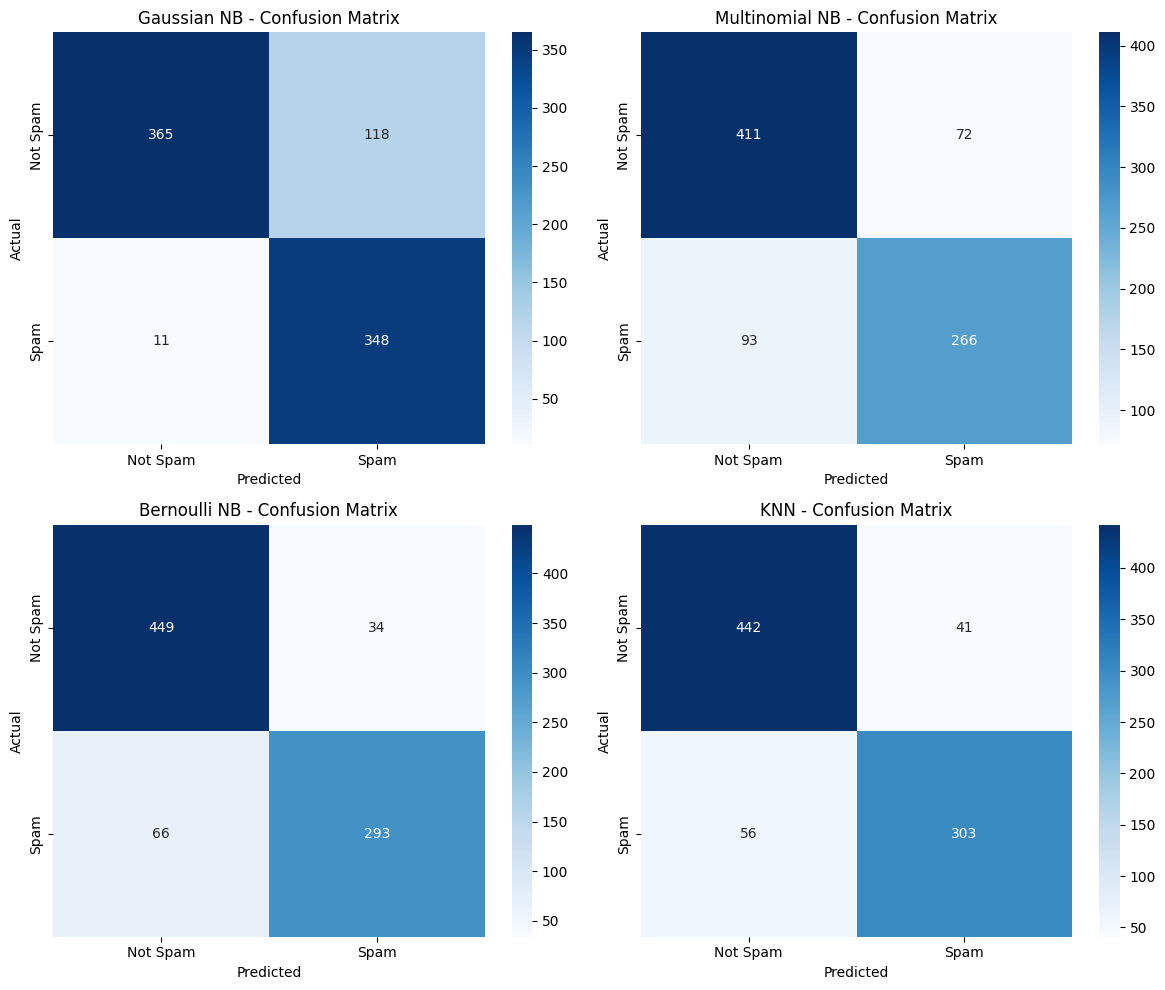

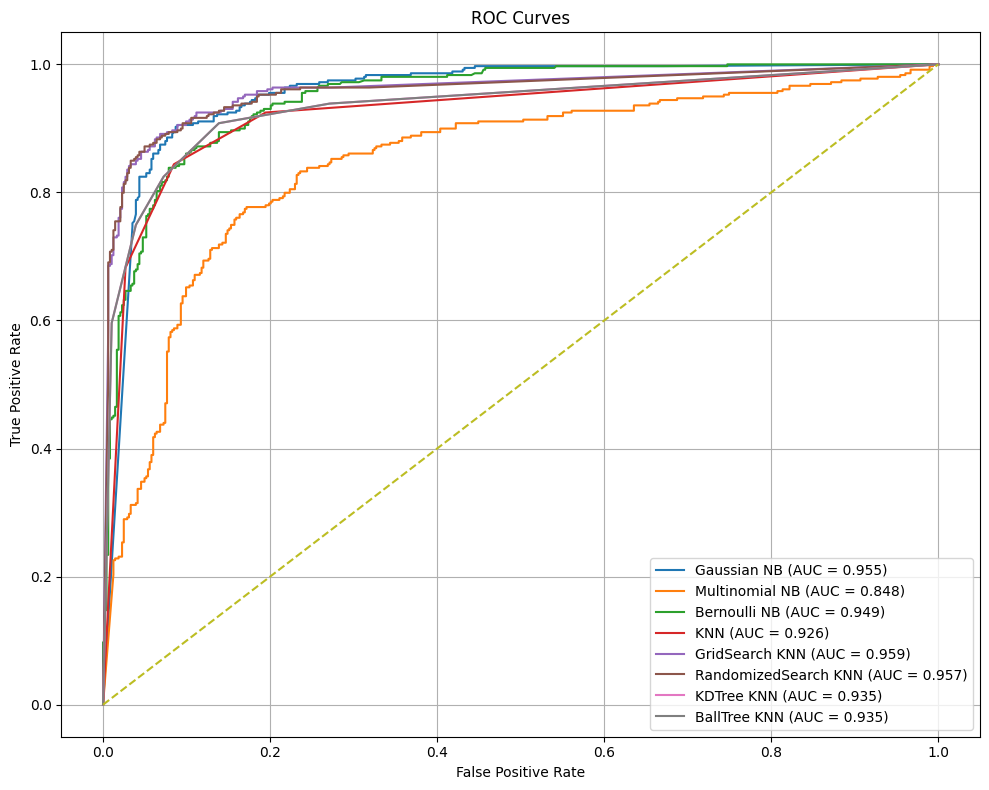

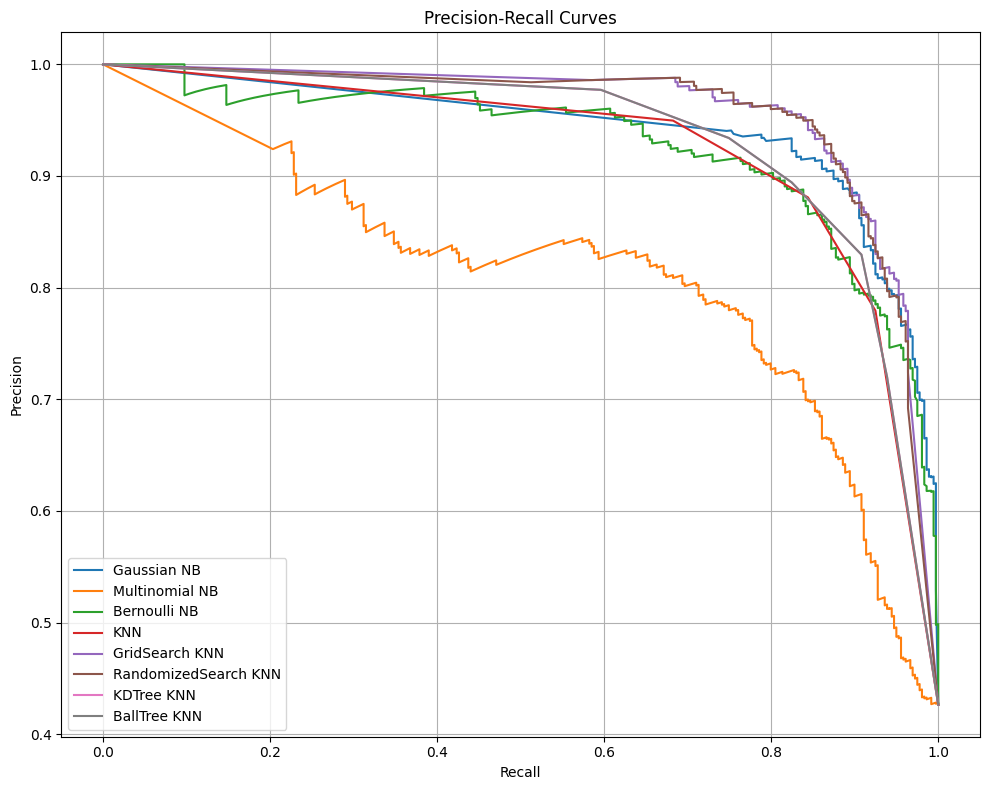

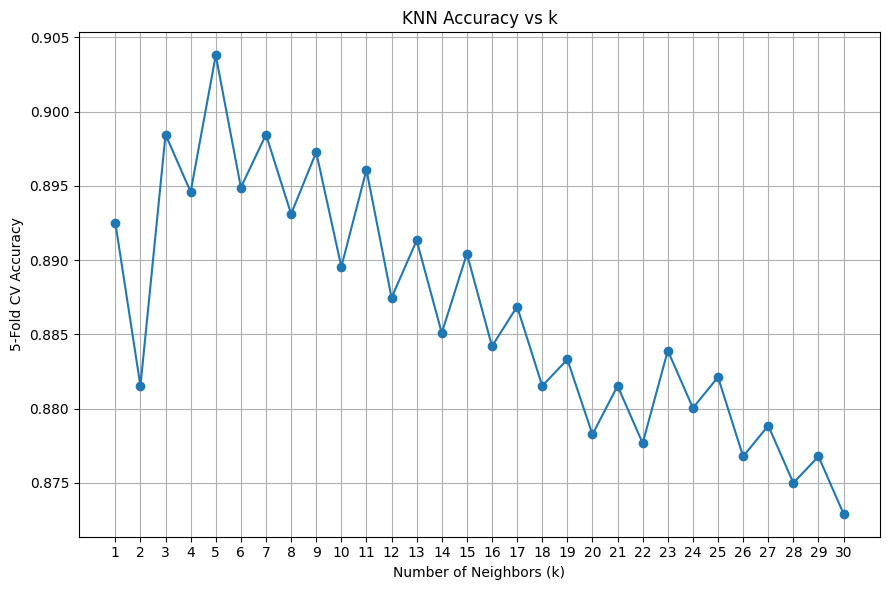

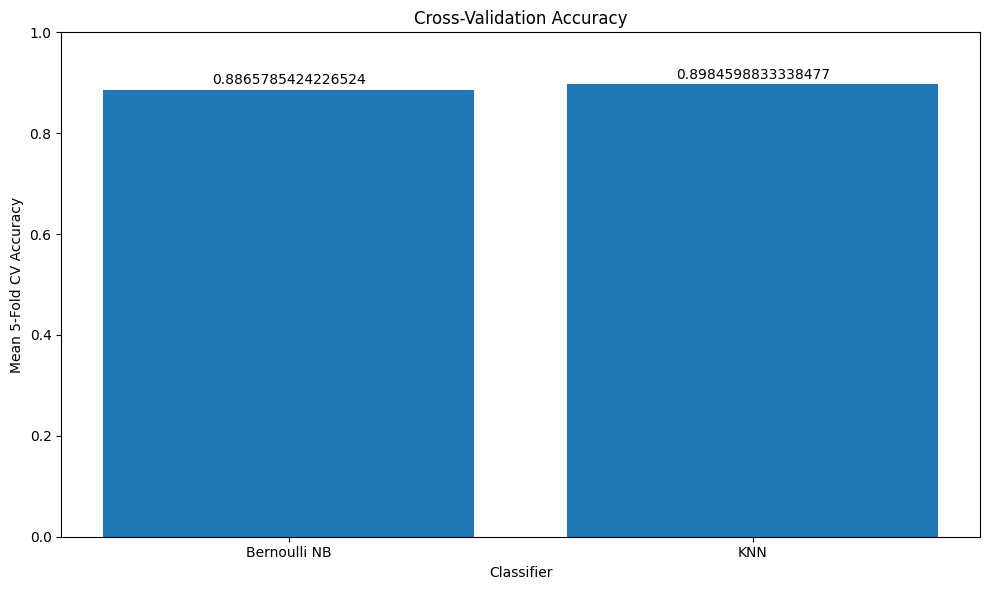

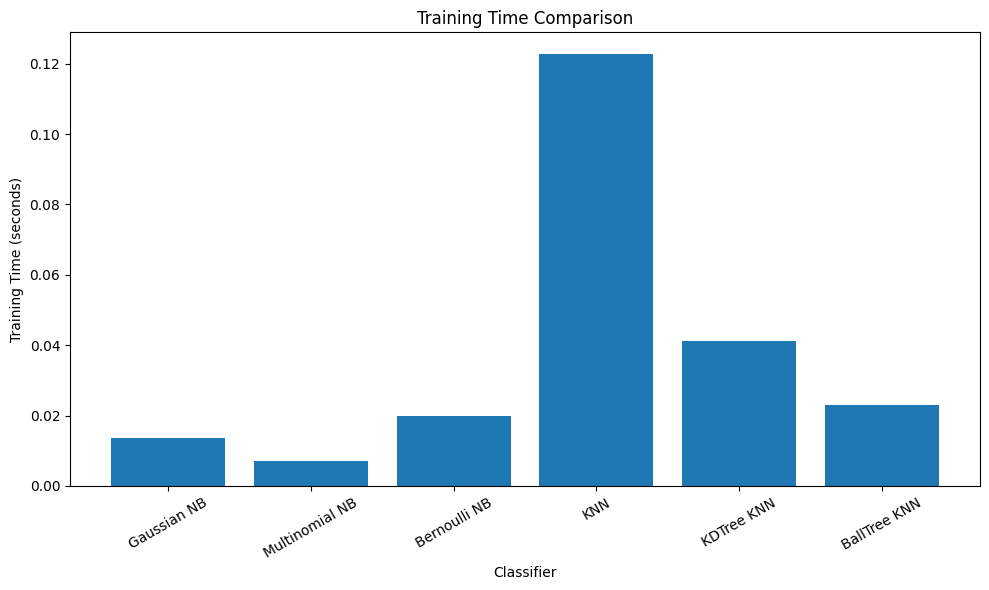

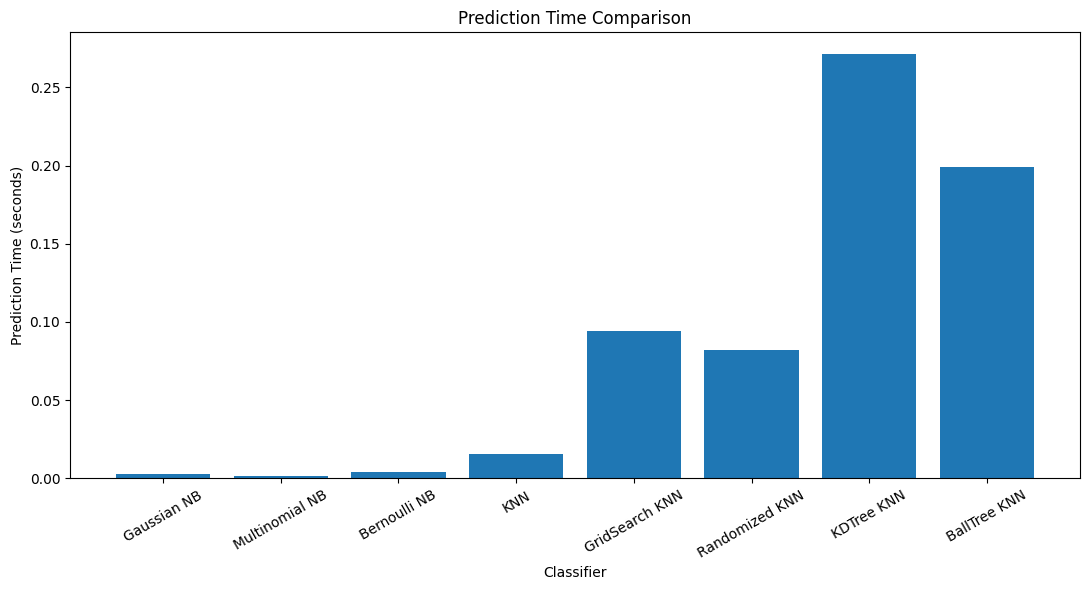

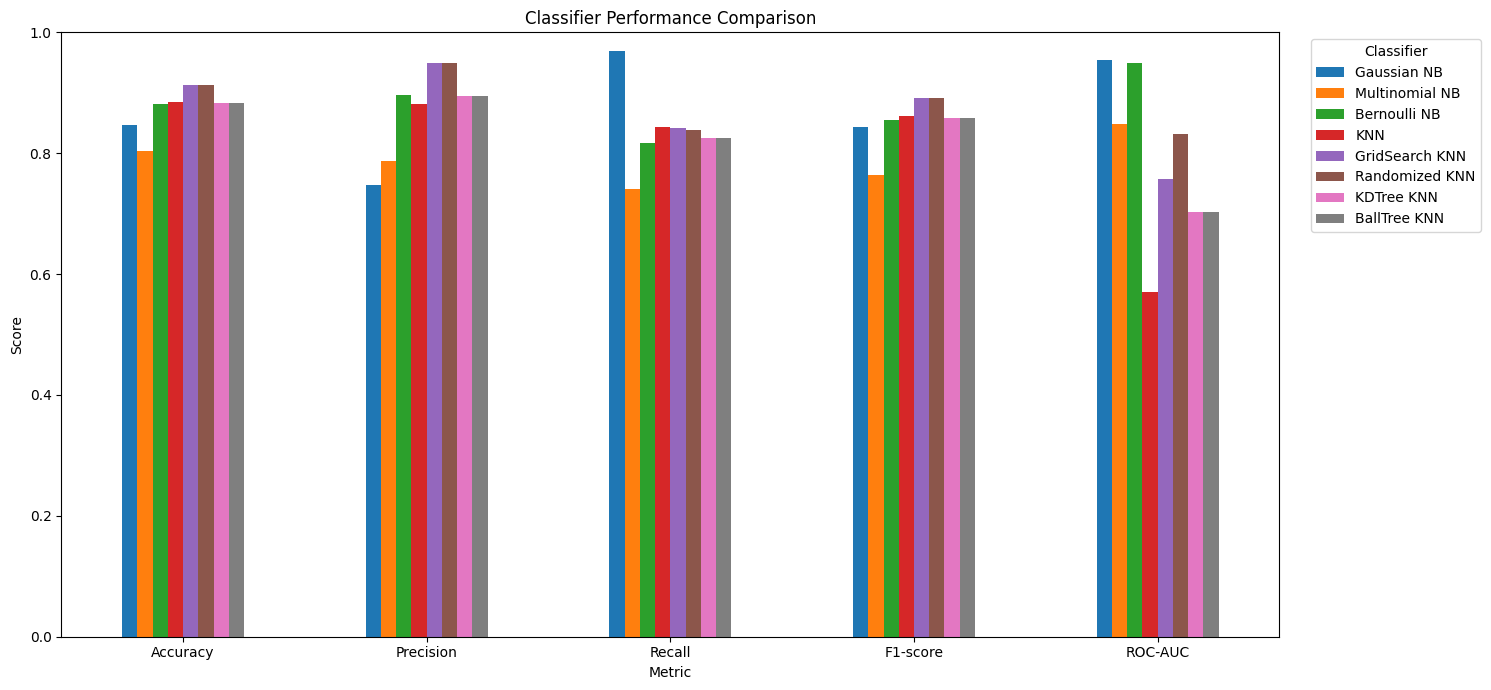

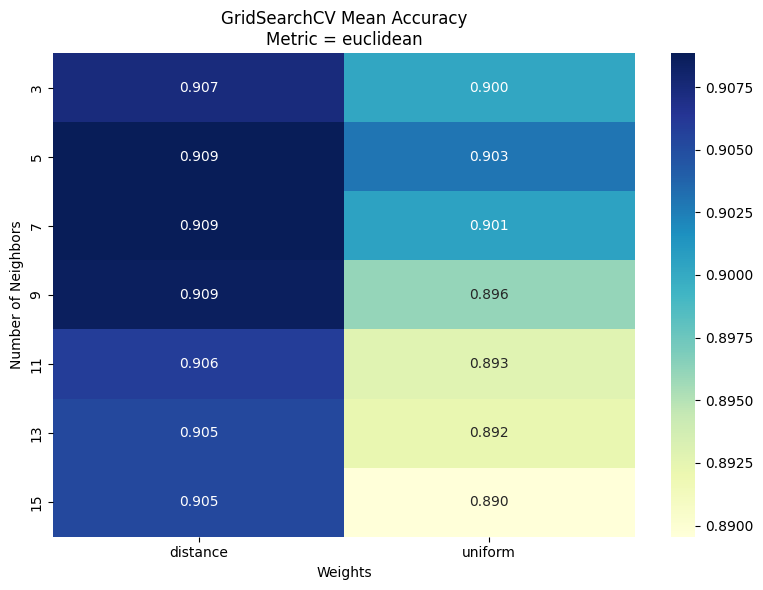

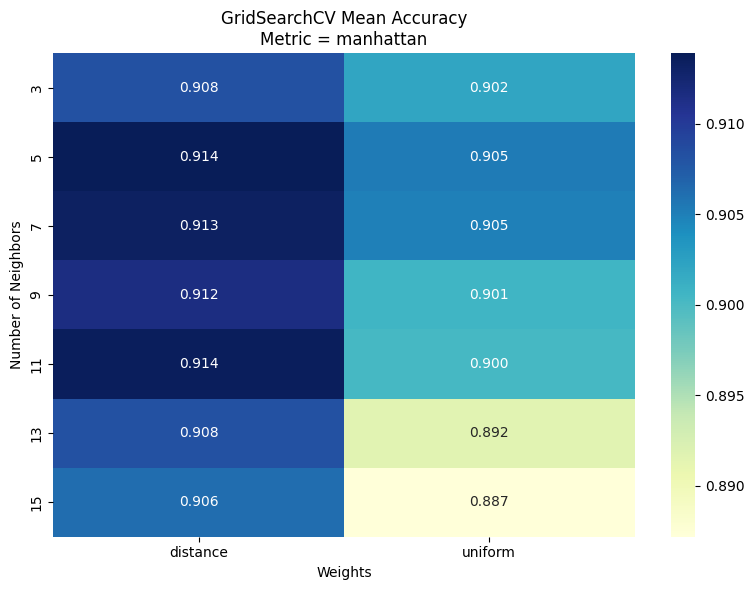

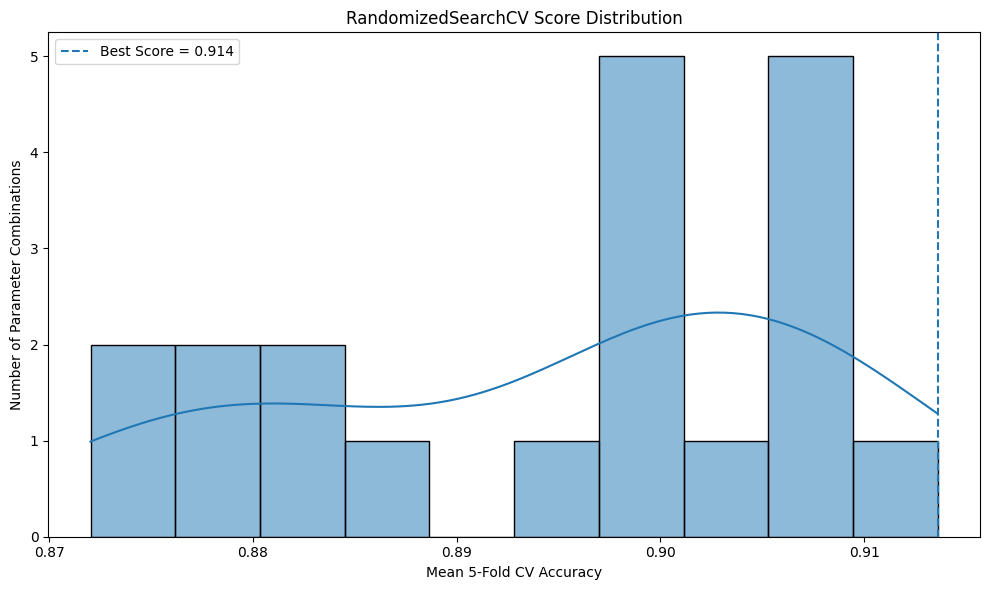

In [24]:
%matplotlib inline
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_score


# Class distribution
plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Not Spam", "Spam"])
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(),cmap="coolwarm",center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Confusion matrix for each model
confusion_matrices = {
    "Gaussian NB": cm_gnb,
    "Multinomial NB": cm_mnb,
    "Bernoulli NB": cm_bnb,
    "KNN": cm_knn
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, cm) in zip(axes.ravel(), confusion_matrices.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Not Spam", "Spam"],
        yticklabels=["Not Spam", "Spam"]
    )
    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()



# ROC Curves
models = {
    "Gaussian NB": gnb,
    "Multinomial NB": mnb,
    "Bernoulli NB": bnb,
    "KNN": knn,
    "GridSearch KNN": grid_search,
    "RandomizedSearch KNN": random_search,
    "KDTree KNN": knn_kd,
    "BallTree KNN": knn_ball
}

test_data = {
    "Gaussian NB": x_test,
    "Multinomial NB": x_test,
    "Bernoulli NB": x_test,
    "KNN": x_test_sc,
    "GridSearch KNN": x_test_sc,
    "RandomizedSearch KNN": x_test_sc,
    "KDTree KNN": x_test_sc,
    "BallTree KNN": x_test_sc
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    X_data = test_data[name]
    y_prob = model.predict_proba(X_data)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()



# Precision recall curves
plt.figure(figsize=(10, 8))
for name, model in models.items():
    X_data = test_data[name]
    y_prob = model.predict_proba(X_data)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()



# Accuracy vs K
k_values = range(1, 31)
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        model,
        x_train_sc,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    k_accuracies.append(scores.mean())

plt.figure(figsize=(9, 6))
plt.plot(k_values, k_accuracies, marker="o")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("5-Fold CV Accuracy")
plt.title("KNN Accuracy vs k")
plt.xticks(list(k_values))
plt.grid()
plt.tight_layout()
plt.show()



# Cross-validation accuracy
cv_results = {
    "Bernoulli NB": scores_bnb,
    "KNN": scores_knn
}
cv_means = {
    name: scores.mean()
    for name, scores in cv_results.items()
}
plt.figure(figsize=(10, 6))
plt.bar(
    cv_means.keys(),
    cv_means.values()
)
plt.xlabel("Classifier")
plt.ylabel("Mean 5-Fold CV Accuracy")
plt.title("Cross-Validation Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(cv_means.values()):
    plt.text(
        i,
        value + 0.01,
        f"{value}",
        ha="center"
    )

plt.tight_layout()
plt.show()



# Training time comparison

training_times = {
    "Gaussian NB" : gnb_train_time,
    "Multinomial NB" : mnb_train_time,
    "Bernoulli NB" : bnb_train_time,
    "KNN" : knn_train_time,
    "KDTree KNN" : train_time_kd,
    "BallTree KNN" : train_time_ball}

plt.figure(figsize=(10, 6))

plt.bar(
    training_times.keys(),
    training_times.values()
)

plt.xlabel("Classifier")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



# prediction times comparison
prediction_times = {}

for name, model in {
    "Gaussian NB": gnb,
    "Multinomial NB": mnb,
    "Bernoulli NB": bnb
}.items():

    start = time.perf_counter()
    model.predict(x_test)
    prediction_times[name] = time.perf_counter() - start


start = time.perf_counter()
knn.predict(x_test_sc)
prediction_times["KNN"] = time.perf_counter() - start

start = time.perf_counter()
grid_search.predict(x_test_sc)
prediction_times["GridSearch KNN"] = time.perf_counter() - start

start = time.perf_counter()
random_search.predict(x_test_sc)
prediction_times["Randomized KNN"] = time.perf_counter() - start

start = time.perf_counter()
knn_kd.predict(x_test_sc)
prediction_times["KDTree KNN"] = time.perf_counter() - start

start = time.perf_counter()
knn_ball.predict(x_test_sc)
prediction_times["BallTree KNN"] = time.perf_counter() - start

plt.figure(figsize=(11, 6))

plt.bar(
    prediction_times.keys(),
    prediction_times.values()
)

plt.xlabel("Classifier")
plt.ylabel("Prediction Time (seconds)")
plt.title("Prediction Time Comparison")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



# classifier comparison chart 


classifier_metrics = pd.DataFrame({
    "Gaussian NB": [
        accuracy_gnb,
        precision_gnb,
        recall_gnb,
        f1_gnb,
        roc_auc_gnb
    ],
    "Multinomial NB": [
        accuracy_mnb,
        precision_mnb,
        recall_mnb,
        f1_mnb,
        roc_auc_mnb
    ],
    "Bernoulli NB": [
        accuracy_bnb,
        precision_bnb,
        recall_bnb,
        f1_bnb,
        roc_auc_bnb
    ],
    "KNN": [
        accuracy_knn,
        precision_knn,
        recall_knn,
        f1_knn,
        roc_auc_knn
    ],
    "GridSearch KNN": [
        accuracy_knn_grid,
        precision_knn_grid,
        recall_knn_grid,
        f1_knn_grid,
        roc_auc_knn_grid
    ],
    "Randomized KNN": [
        accuracy_knn_random,
        precision_knn_random,
        recall_knn_random,
        f1_knn_random,
        roc_auc_knn_random
    ],
    "KDTree KNN": [
        accuracy_kd,
        precision_kd,
        recall_kd,
        f1_kd,
        roc_auc_kd
    ],
    "BallTree KNN": [
        accuracy_ball,
        precision_ball,
        recall_ball,
        f1_ball,
        roc_auc_ball
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
])

classifier_metrics.plot(
    kind="bar",
    figsize=(15, 7)
)

plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Classifier Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Classifier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



# GridSearchCV Heatmap

grid_results = pd.DataFrame(grid_search.cv_results_)
for metric in grid_results["param_metric"].unique():

    subset = grid_results[
        grid_results["param_metric"] == metric
    ]

    pivot_table = subset.pivot_table(
        index="param_n_neighbors",
        columns="param_weights",
        values="mean_test_score"
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        pivot_table,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu"
    )

    plt.title(
        f"GridSearchCV Mean Accuracy\nMetric = {metric}"
    )
    plt.xlabel("Weights")
    plt.ylabel("Number of Neighbors")
    plt.tight_layout()
    plt.show()



# RandomSearchCV scores comparison
random_results = pd.DataFrame(
    random_search.cv_results_
)

plt.figure(figsize=(10, 6))

sns.histplot(
    random_results["mean_test_score"],
    bins=10,
    kde=True
)

plt.axvline(
    random_search.best_score_,
    linestyle="--",
    label=f"Best Score = {random_search.best_score_:.3f}"
)

plt.xlabel("Mean 5-Fold CV Accuracy")
plt.ylabel("Number of Parameter Combinations")
plt.title("RandomizedSearchCV Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()